
# 07 - Comparación de intervalos de predicción

Este notebook compara, sobre el conjunto de validación (2024), los intervalos de predicción obtenidos en los notebooks anteriores:

- Modelo base ingenuo estacional + split conformal (`06a_split_conformal_baseline.ipynb`)
- Regresión lineal + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- LightGBM + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- CatBoost + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)

Y, por otra parte, genera:

1. Métricas de los intervalos de predicción usando todas las predicciones disponibles
2. Métricas de los intervalos de predicción restringidas a los instantes objetivo que son comunes a todos los métodos
3. Tablas comparativas y una selección preliminar del mejor método por horizonte
4. Figuras relevantes que muestren claramente la comparación buscada.



## Criterio de comparación

La comparación principal del notebook se realizará sobre los instantes objetivo comunes a todos los métodos para cada horizonte. De esta manera, se evita comparar intervalos calculados sobre subconjuntos distintos de observaciones.

Se evaluarán las siguientes métricas, tal y como se ha establecido en la memoria:

- Cobertura empírica
- Anchura media
- Interval score


In [21]:

from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from IPython.display import display


In [22]:

# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS: list[int] = [1, 4, 12, 24]
VALIDATION_SPLIT = "validation"
ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 7 * 24  # una semana continua para la figura de ejemplo

MODEL_REGISTRY: dict[str, dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "interval_prefix": "split_conformal_baseline",
        "method": "split_conformal",
        "method_display": "Split conformal",
        "label": "Modelo base + SC",
        "color": "tab:blue",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Lineal",
        "interval_prefix": "cqr_linear_regression",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "Regresión lineal + CQR",
        "color": "tab:green",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LGBM",
        "interval_prefix": "cqr_lightgbm",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "LightGBM + CQR",
        "color": "tab:red",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CAT",
        "interval_prefix": "cqr_catboost",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "CatBoost + CQR",
        "color": "tab:purple",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
MODEL_ORDER_MAP = {model_id: idx for idx, model_id in enumerate(MODEL_ORDER)}
HORIZON_MARKERS = {1: "o", 4: "s", 12: "^", 24: "D"}

# Se define una sola vez para evitar inconsistencias entre figuras.
SPANISH_MONTH_NAMES = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")


Raíz del proyecto: c:\trabajo_github
Intervalos: c:\trabajo_github\reports\intervals
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Cobertura nominal: 80%


In [23]:

# Funciones auxiliares

def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para los intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty


def first_existing_column(df: pd.DataFrame, candidates: Sequence[str], purpose: str) -> str:
    """Devuelve la primera columna existente dentro de una lista de candidatas."""
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"No se encontró ninguna columna para {purpose}.\n"
        f"Candidatas probadas: {list(candidates)}\n"
        f"Columnas disponibles: {list(df.columns)}"
    )


def get_model_label(model_id: str) -> str:
    """Devuelve una etiqueta legible para el modelo."""
    if model_id in MODEL_REGISTRY:
        meta = MODEL_REGISTRY[model_id]
        return meta.get("display_name") or meta.get("label") or meta.get("short_name") or model_id
    return model_id


def sort_by_horizon_and_model(df: pd.DataFrame) -> pd.DataFrame:
    """Ordena tablas usando el orden conceptual de modelos definido arriba."""
    out = df.copy()
    if "model" in out.columns:
        out["_model_order"] = out["model"].map(MODEL_ORDER_MAP)
        out = out.sort_values(["horizon", "_model_order"]).drop(columns="_model_order")
    else:
        out = out.sort_values("horizon")
    return out.reset_index(drop=True)


def spanish_axis_date(x: float, pos: int | None = None) -> str:
    """Formato de fecha para ejes con día, mes en español y año."""
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {SPANISH_MONTH_NAMES[dt.month]} {dt.year}"


def format_spanish_date(ts: pd.Timestamp | str) -> str:
    """Formato de fecha en español para títulos."""
    ts = pd.Timestamp(ts)
    return f"{ts.day:02d} {SPANISH_MONTH_NAMES[ts.month]} {ts.year}"


def format_quantile_label(q: float) -> str:
    """Formato decimal con coma para etiquetas matemáticas en español."""
    return f"{q:.2f}".replace(".", "{,}")


def configure_spanish_date_axis(
    ax: plt.Axes,
    tick_dates: Iterable[pd.Timestamp] | None = None,
    locator: mdates.DateLocator | None = None,
    labelsize: int | None = None,
    rotation: int = 0,
) -> None:
    """Aplica el formateo común de fechas en español a un eje temporal."""
    if tick_dates is not None:
        ax.set_xticks(list(tick_dates))
    if locator is not None:
        ax.xaxis.set_major_locator(locator)

    ax.xaxis.set_major_formatter(FuncFormatter(spanish_axis_date))
    ax.tick_params(axis="x", labelsize=labelsize, rotation=rotation)
    plt.setp(ax.get_xticklabels(), ha="center")


def common_ylim_from_blocks(
    blocks: Iterable[pd.DataFrame],
    columns: Sequence[str],
    margin_fraction: float = 0.08,
) -> tuple[float, float]:
    """Calcula límites verticales comunes para varias figuras/paneles."""
    values = pd.concat([block[list(columns)].stack() for block in blocks], axis=0).dropna()

    if values.empty:
        raise ValueError("No hay valores válidos para calcular un rango vertical común.")

    y_min = float(values.min())
    y_max = float(values.max())
    y_margin = margin_fraction * (y_max - y_min)

    if y_margin == 0:
        y_margin = 1.0

    return y_min - y_margin, y_max + y_margin


def save_dataframe_csv(df: pd.DataFrame, path: Path, **kwargs: Any) -> Path:
    """Guarda una tabla y muestra una traza uniforme en pantalla."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, **kwargs)
    print(f"Tabla guardada: {path}")
    return path


SAVED_FIGURE_PATHS: list[Path] = []


def save_figure(
    fig: plt.Figure,
    path: Path,
    *,
    aliases: Sequence[Path] | None = None,
    **savefig_kwargs: Any,
) -> list[Path]:
    """Guarda una figura, opcionalmente con nombres alternativos."""
    default_kwargs: dict[str, Any] = {"dpi": 300, "bbox_inches": "tight"}
    default_kwargs.update(savefig_kwargs)

    paths = [path, *(aliases or [])]
    saved_paths = []

    for output_path in paths:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **default_kwargs)
        SAVED_FIGURE_PATHS.append(output_path)
        saved_paths.append(output_path)
        print(f"Figura guardada en: {output_path}")

    return saved_paths


def configure_horizon_axis(ax: plt.Axes) -> None:
    """Formato común para figuras cuyo eje x es el horizonte."""
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)


def select_continuous_block(df: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de `n_hours`; si no existe, usa el mayor."""
    work = df.sort_values("target_timestamp").copy()
    work["delta_h"] = work["target_timestamp"].diff() / pd.Timedelta(hours=1)
    work["block_id"] = (work["delta_h"].isna() | (work["delta_h"] != 1)).cumsum()

    summary = (
        work.groupby("block_id")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidates = summary.loc[summary["n_hours"] >= n_hours]

    if candidates.empty:
        block_id = summary.sort_values(["n_hours", "start"], ascending=[False, True]).iloc[0]["block_id"]
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        block_id = candidates.sort_values("start").iloc[0]["block_id"]

    selected = work.loc[work["block_id"] == block_id].copy().head(n_hours)
    return selected.drop(columns=["delta_h", "block_id"], errors="ignore").reset_index(drop=True)


def find_candidate_continuous_windows(
    timestamps: pd.Series,
    n_hours: int,
    prefer_daily_starts: bool = True,
) -> list[dict[str, Any]]:
    """Encuentra todos los tramos horarios continuos de longitud n_hours."""
    timestamps = (
        pd.to_datetime(timestamps)
        .dropna()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    available_timestamps = set(pd.DatetimeIndex(timestamps))
    candidate_starts = timestamps.copy()

    if prefer_daily_starts:
        daily_starts = candidate_starts.loc[candidate_starts.dt.hour == 0]
        if not daily_starts.empty:
            candidate_starts = daily_starts

    candidate_windows = []

    for candidate_start in candidate_starts:
        expected_range = pd.date_range(start=candidate_start, periods=n_hours, freq="h")

        if all(ts in available_timestamps for ts in expected_range):
            candidate_windows.append(
                {
                    "start": candidate_start,
                    "end": expected_range[-1],
                    "target_timestamps": expected_range,
                }
            )

    return candidate_windows


def detect_baseline_mask(df: pd.DataFrame) -> pd.Series:
    """
    Detecta filas del modelo base de forma flexible.

    Se buscan términos como baseline, base, naive, ingenuo, seasonal o split
    en columnas textuales como model, label, method o model_id, excluyendo
    explícitamente modelos supervisados.
    """
    preferred_text_cols = ["model", "label", "method", "model_id", "estimator"]
    text_cols = [col for col in preferred_text_cols if col in df.columns]

    if not text_cols:
        # Si no hay columnas textuales de identificación, se asume que la fuente
        # ya corresponde al modelo base. Esto suele ocurrir si se usa baseline_intervals.
        print(
            "No se encontraron columnas textuales de identificación; "
            "se asume que todas las filas corresponden al modelo base."
        )
        return pd.Series(True, index=df.index)

    combined_text = df[text_cols].astype(str).agg(" ".join, axis=1).str.lower()

    include_patterns = ["baseline", "modelo base", "base", "naive", "ingenuo", "seasonal", "split"]
    exclude_patterns = [
        "catboost",
        "lightgbm",
        "lgbm",
        "linear",
        "lineal",
        "regresión lineal",
        "regresion lineal",
        "cqr",
    ]

    include_mask = combined_text.str.contains("|".join(include_patterns), regex=True, na=False)
    exclude_mask = combined_text.str.contains("|".join(exclude_patterns), regex=True, na=False)
    baseline_mask = include_mask & ~exclude_mask

    if not baseline_mask.any():
        available_info = {
            col: df[col].dropna().astype(str).drop_duplicates().sort_values().tolist()
            for col in text_cols
        }
        raise KeyError(
            "No se pudo identificar el modelo base de forma automática.\n"
            f"Columnas revisadas: {text_cols}\n"
            f"Valores disponibles: {available_info}"
        )

    print(f"Filas detectadas como modelo base: {baseline_mask.sum()}")

    for col in text_cols:
        values = df.loc[baseline_mask, col].dropna().astype(str).drop_duplicates().sort_values().tolist()
        if values:
            print(f"Valores detectados en '{col}': {values}")

    return baseline_mask


In [24]:

# Funciones específicas para los intervalos

def standardize_interval_frame(df: pd.DataFrame, model_id: str, horizon: int) -> pd.DataFrame:
    """Armoniza columnas y añade metadatos de modelo/horizonte."""
    meta = MODEL_REGISTRY[model_id]
    out = df.copy()

    for col in ["origin_timestamp", "target_timestamp"]:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col])

    out = out.assign(
        model=model_id,
        model_display=meta["display_name"],
        method=meta["method"],
        method_display=meta["method_display"],
        label=meta["label"],
        short_name=meta["short_name"],
        color=meta["color"],
        horizon=horizon,
        split=VALIDATION_SPLIT,
    )

    required = ["target_timestamp", "y_true", "lower", "upper"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas en {model_id}, h={horizon}: {missing}")

    out["interval_width"] = out["upper"] - out["lower"]
    out["covered"] = (out["y_true"] >= out["lower"]) & (out["y_true"] <= out["upper"])
    out["miss_lower"] = out["y_true"] < out["lower"]
    out["miss_upper"] = out["y_true"] > out["upper"]
    out["interval_score"] = interval_score(out["y_true"], out["lower"], out["upper"], ALPHA)

    # Columna unificada de predicción puntual de referencia para la figura de ejemplo.
    point_candidates = [
        "y_pred_reference",
        "y_pred_point",
        "y_pred",
        "y_pred_mapie",
        "y_pred_quantile_median",
    ]
    point_col = next((candidate for candidate in point_candidates if candidate in out.columns), None)
    out["y_pred_reference"] = out[point_col] if point_col is not None else np.nan

    return out


def compute_interval_metrics(df: pd.DataFrame) -> dict[str, Any]:
    """Resume las métricas de intervalos."""
    coverage = float(df["covered"].mean())
    return {
        "model": df["model"].iloc[0],
        "model_display": df["model_display"].iloc[0],
        "method": df["method"].iloc[0],
        "method_display": df["method_display"].iloc[0],
        "label": df["label"].iloc[0],
        "horizon": int(df["horizon"].iloc[0]),
        "alpha": ALPHA,
        "nominal_coverage": NOMINAL_COVERAGE,
        "n_samples": int(len(df)),
        "empirical_coverage": coverage,
        "coverage_error": coverage - NOMINAL_COVERAGE,
        "coverage_abs_error": abs(coverage - NOMINAL_COVERAGE),
        "mean_width": float(df["interval_width"].mean()),
        "median_width": float(df["interval_width"].median()),
        "mean_interval_score": float(df["interval_score"].mean()),
        "median_interval_score": float(df["interval_score"].median()),
        "miss_lower_rate": float(df["miss_lower"].mean()),
        "miss_upper_rate": float(df["miss_upper"].mean()),
        "target_start": df["target_timestamp"].min(),
        "target_end": df["target_timestamp"].max(),
    }


def build_metrics_table(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula métricas por modelo y horizonte."""
    rows = [
        compute_interval_metrics(group)
        for (_model_id, _horizon), group in df.groupby(["model", "horizon"], sort=False)
    ]
    return sort_by_horizon_and_model(pd.DataFrame(rows))


def rank_metrics_by_horizon(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Ordena por interval score, error absoluto de cobertura y anchura."""
    ranked_frames = []

    for horizon, group in metrics_df.groupby("horizon", sort=True):
        ranked = group.sort_values(
            ["mean_interval_score", "coverage_abs_error", "mean_width"],
            ascending=[True, True, True],
        ).copy()
        ranked["rank_interval_score"] = np.arange(1, len(ranked) + 1)
        ranked_frames.append(ranked)

    return pd.concat(ranked_frames, ignore_index=True).sort_values(
        ["horizon", "rank_interval_score"]
    ).reset_index(drop=True)



## Carga y estandarización de los intervalos

Se cargan los archivos `.parquet` generados por los notebooks `06a_split_conformal_baseline` y `06b_cqr_supervised_models`. Después, se armonizarán sus columnas para construir una sola tabla.


In [25]:

# Carga de los archivos con la información de los intervalos

def load_validation_intervals() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Carga todos los intervalos definidos en MODEL_REGISTRY y HORIZONS."""
    interval_frames = []
    loaded_files = []

    for model_id in MODEL_ORDER:
        meta = MODEL_REGISTRY[model_id]

        for horizon in HORIZONS:
            path = REPORTS_INTERVALS_DIR / f"{meta['interval_prefix']}_h{horizon:02d}.parquet"

            if not path.exists():
                raise FileNotFoundError(
                    f"No se ha encontrado {path}. Ejecuta antes los notebooks 06a y 06b."
                )

            df_h = pd.read_parquet(path)
            df_h = standardize_interval_frame(df_h, model_id=model_id, horizon=horizon)
            interval_frames.append(df_h)
            loaded_files.append(
                {"model": model_id, "horizon": horizon, "path": str(path), "n_rows": len(df_h)}
            )

    all_intervals = pd.concat(interval_frames, ignore_index=True)
    all_intervals = all_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)
    loaded_files_df = pd.DataFrame(loaded_files)

    # Se trabaja únicamente con validación externa.
    validation_intervals = all_intervals.loc[all_intervals["split"] == VALIDATION_SPLIT].copy()
    validation_intervals = validation_intervals.sort_values(
        ["horizon", "model", "target_timestamp"]
    ).reset_index(drop=True)

    # Comprobación de duplicados.
    duplicated_counts = (
        validation_intervals.groupby(["model", "horizon", "target_timestamp"])
        .size()
        .reset_index(name="n")
    )
    max_dup = int(duplicated_counts["n"].max())
    assert max_dup == 1, "Existen instantes objetivo duplicados para algún método."

    return all_intervals, validation_intervals, loaded_files_df


all_intervals, validation_intervals, loaded_files_df = load_validation_intervals()

print(f"Archivos cargados: {len(loaded_files_df)}")
print(f"Intervalos totales en validación: {len(validation_intervals):,}")
display(loaded_files_df)
validation_intervals.head()


Archivos cargados: 16
Intervalos totales en validación: 134,304


,model,horizon,path,n_rows
0,baseline_seasonal_naive,1,c:\trabajo_github\reports\intervals\split_conf...,8265
1,baseline_seasonal_naive,4,c:\trabajo_github\reports\intervals\split_conf...,8265
2,baseline_seasonal_naive,12,c:\trabajo_github\reports\intervals\split_conf...,8265
3,baseline_seasonal_naive,24,c:\trabajo_github\reports\intervals\split_conf...,8265
4,linear_regression,1,c:\trabajo_github\reports\intervals\cqr_linear...,8437
5,linear_regression,4,c:\trabajo_github\reports\intervals\cqr_linear...,8437
6,linear_regression,12,c:\trabajo_github\reports\intervals\cqr_linear...,8437
7,linear_regression,24,c:\trabajo_github\reports\intervals\cqr_linear...,8437
8,lightgbm,1,c:\trabajo_github\reports\intervals\cqr_lightg...,8437
9,lightgbm,4,c:\trabajo_github\reports\intervals\cqr_lightg...,8437


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display,method,alpha,nominal_coverage,q_hat,lower,upper,interval_width,covered,miss_lower,miss_upper,interval_score,method_display,label,short_name,color,y_pred_reference,lower_quantile,upper_quantile,q_level,y_pred_quantile_median,y_pred_mapie,lower_prelim,upper_prelim,raw_interval_width,y_pred_point
0,1,validation,2023-12-31 23:00:00,2024-01-01 00:00:00,5.000,5.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 00:00:00,23.000,True,0.000,0.000,0.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-22.000,32.000,54.000,True,False,False,54.000,Split conformal,Modelo base + SC,Baseline,tab:blue,5.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,validation,2024-01-01 00:00:00,2024-01-01 01:00:00,10.000,9.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 01:00:00,23.000,True,1.000,1.000,1.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-18.000,36.000,54.000,True,False,False,54.000,Split conformal,Modelo base + SC,Baseline,tab:blue,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,validation,2024-01-01 01:00:00,2024-01-01 02:00:00,6.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 02:00:00,23.000,True,-11.000,11.000,121.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Modelo base + SC,Baseline,tab:blue,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,validation,2024-01-01 02:00:00,2024-01-01 03:00:00,2.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 03:00:00,23.000,True,-15.000,15.000,225.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Modelo base + SC,Baseline,tab:blue,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,validation,2024-01-01 03:00:00,2024-01-01 04:00:00,2.000,15.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 04:00:00,23.000,True,-13.000,13.000,169.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-12.000,42.000,54.000,True,False,False,54.000,Split conformal,Modelo base + SC,Baseline,tab:blue,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Disponibilidad de las predicciones y de los instantes objetivo comunes

El modelo base y los modelos supervisados no tienen exactamente el mismo número de predicciones evaluables. Por este motivo, se construirán dos tablas:

- Una que informe del número de intervalos disponibles por horizonte
- Una segunda que intersecte los `target_timestamp` entre todos los métodos.


In [26]:

# Disponibilidad y conjunto común de instantes objetivo

def build_common_interval_tables(
    validation_intervals: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Construye disponibilidad, instantes comunes y tabla filtrada común."""
    availability_rows = []
    common_target_rows = []
    common_frames = []

    for horizon in HORIZONS:
        subset_h = validation_intervals.loc[validation_intervals["horizon"] == horizon].copy()

        target_sets = {}
        for model_id in MODEL_ORDER:
            model_df = subset_h.loc[subset_h["model"] == model_id].copy()
            target_sets[model_id] = set(model_df["target_timestamp"])

            availability_rows.append(
                {
                    "horizon": horizon,
                    "model": model_id,
                    "model_display": MODEL_REGISTRY[model_id]["display_name"],
                    "method": MODEL_REGISTRY[model_id]["method"],
                    "label": MODEL_REGISTRY[model_id]["label"],
                    "n_available": int(len(model_df)),
                    "target_start": model_df["target_timestamp"].min(),
                    "target_end": model_df["target_timestamp"].max(),
                }
            )

        common_targets = sorted(set.intersection(*target_sets.values()))

        common_target_rows.append(
            {
                "horizon": horizon,
                "n_common_targets": int(len(common_targets)),
                "common_target_start": common_targets[0] if common_targets else pd.NaT,
                "common_target_end": common_targets[-1] if common_targets else pd.NaT,
            }
        )

        for model_id in MODEL_ORDER:
            model_common = subset_h.loc[
                (subset_h["model"] == model_id)
                & (subset_h["target_timestamp"].isin(common_targets))
            ].copy()
            common_frames.append(model_common)

    availability_df = sort_by_horizon_and_model(pd.DataFrame(availability_rows))
    common_target_counts_df = pd.DataFrame(common_target_rows).sort_values("horizon").reset_index(drop=True)
    common_intervals = pd.concat(common_frames, ignore_index=True)
    common_intervals = common_intervals.sort_values(
        ["horizon", "model", "target_timestamp"]
    ).reset_index(drop=True)

    # Tabla resumen con la disponibilidad y el tamaño del conjunto común.
    comparison_target_counts_df = availability_df.merge(common_target_counts_df, on="horizon", how="left")
    comparison_target_counts_df["pct_common_over_available"] = np.where(
        comparison_target_counts_df["n_available"] > 0,
        100
        * comparison_target_counts_df["n_common_targets"]
        / comparison_target_counts_df["n_available"],
        np.nan,
    )

    return availability_df, common_target_counts_df, common_intervals, comparison_target_counts_df


(
    availability_df,
    common_target_counts_df,
    common_intervals,
    comparison_target_counts_df,
) = build_common_interval_tables(validation_intervals)

print("Disponibilidad de predicciones por método y horizonte:")
display(comparison_target_counts_df)

print("Instantes comunes por horizonte:")
display(common_target_counts_df)


Disponibilidad de predicciones por método y horizonte:


,horizon,model,model_display,method,label,n_available,target_start,target_end,n_common_targets,common_target_start,common_target_end,pct_common_over_available
0,1,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Modelo base + SC,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
1,1,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
2,1,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
3,1,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
4,4,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Modelo base + SC,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
5,4,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
6,4,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
7,4,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
8,12,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Modelo base + SC,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
9,12,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961


Instantes comunes por horizonte:


,horizon,n_common_targets,common_target_start,common_target_end
0,1,8265,2024-01-01,2024-12-31 23:00:00
1,4,8265,2024-01-01,2024-12-31 23:00:00
2,12,8265,2024-01-01,2024-12-31 23:00:00
3,24,8265,2024-01-01,2024-12-31 23:00:00



## Métricas de los intervalos

Se calculan dos versiones de la comparación:

1. `available_metrics_df`: usa todas las predicciones disponibles para cada modelo.
2. `common_metrics_df`: usa solo los instantes objetivo comunes a todos los modelos, por lo que servirá como comparativa principal.


In [27]:

# Cálculo de métricas para todas las observaciones disponibles y para los instantes comunes

available_metrics_df = build_metrics_table(validation_intervals)
common_metrics_df = rank_metrics_by_horizon(build_metrics_table(common_intervals))

# Selección preliminar del mejor método por horizonte.
best_method_by_horizon_df = (
    common_metrics_df.sort_values(["horizon", "rank_interval_score"])
    .groupby("horizon", as_index=False)
    .first()
)

# Tabla de las mejoras respecto al modelo base en la comparación principal.
baseline_reference = (
    common_metrics_df.loc[
        common_metrics_df["model"] == "baseline_seasonal_naive",
        ["horizon", "empirical_coverage", "mean_width", "mean_interval_score"],
    ]
    .rename(
        columns={
            "empirical_coverage": "baseline_coverage",
            "mean_width": "baseline_mean_width",
            "mean_interval_score": "baseline_mean_interval_score",
        }
    )
)

improvement_vs_baseline_df = common_metrics_df.merge(baseline_reference, on="horizon", how="left")
improvement_vs_baseline_df = improvement_vs_baseline_df.loc[
    improvement_vs_baseline_df["model"] != "baseline_seasonal_naive"
].copy()
improvement_vs_baseline_df["delta_coverage_vs_baseline"] = (
    improvement_vs_baseline_df["empirical_coverage"]
    - improvement_vs_baseline_df["baseline_coverage"]
)
improvement_vs_baseline_df["width_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_width"]
    - improvement_vs_baseline_df["mean_width"]
)
improvement_vs_baseline_df["interval_score_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_interval_score"]
    - improvement_vs_baseline_df["mean_interval_score"]
)
improvement_vs_baseline_df = improvement_vs_baseline_df.sort_values(
    ["horizon", "rank_interval_score"]
).reset_index(drop=True)

summary_common_df = common_metrics_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "rank_interval_score",
    ]
].copy()
common_metrics_wide_df = summary_common_df.pivot(index="horizon", columns="label")

print("Métricas de intervalos sobre todas las observaciones disponibles:")
display(available_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score"]])

print("Métricas de intervalos sobre instantes objetivo comunes (comparación principal):")
display(common_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score", "rank_interval_score"]])

print("Selección preliminar del mejor método por horizonte:")
display(best_method_by_horizon_df[["horizon", "label", "empirical_coverage", "mean_width", "mean_interval_score"]])


Métricas de intervalos sobre todas las observaciones disponibles:


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score
0,1,Modelo base + SC,8265,0.800,54.000,79.195
1,1,Regresión lineal + CQR,8437,0.804,21.550,32.387
2,1,LightGBM + CQR,8437,0.801,19.679,29.827
3,1,CatBoost + CQR,8437,0.803,19.732,29.626
4,4,Modelo base + SC,8265,0.800,54.000,79.195
5,4,Regresión lineal + CQR,8437,0.798,40.958,54.960
6,4,LightGBM + CQR,8437,0.796,37.045,50.627
7,4,CatBoost + CQR,8437,0.790,35.821,49.702
8,12,Modelo base + SC,8265,0.800,54.000,79.195
9,12,Regresión lineal + CQR,8437,0.789,45.022,60.401


Métricas de intervalos sobre instantes objetivo comunes (comparación principal):


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score,rank_interval_score
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,1
1,1,LightGBM + CQR,8265,0.799,19.687,29.961,2
2,1,Regresión lineal + CQR,8265,0.803,21.547,32.482,3
3,1,Modelo base + SC,8265,0.800,54.000,79.195,4
4,4,CatBoost + CQR,8265,0.790,35.902,49.886,1
5,4,LightGBM + CQR,8265,0.795,37.052,50.826,2
6,4,Regresión lineal + CQR,8265,0.797,40.986,55.085,3
7,4,Modelo base + SC,8265,0.800,54.000,79.195,4
8,12,CatBoost + CQR,8265,0.796,42.207,57.559,1
9,12,LightGBM + CQR,8265,0.792,42.944,58.315,2


Selección preliminar del mejor método por horizonte:


,horizon,label,empirical_coverage,mean_width,mean_interval_score
0,1,CatBoost + CQR,0.802,19.759,29.740
1,4,CatBoost + CQR,0.790,35.902,49.886
2,12,CatBoost + CQR,0.796,42.207,57.559
3,24,CatBoost + CQR,0.779,43.010,59.237


In [28]:

# Guardado de tablas

# En la tabla ancha se conserva el índice porque corresponde al horizonte.
table_outputs = {
    "metrics_available": (available_metrics_df, REPORTS_TABLES_DIR / "interval_metrics_validation_available.csv", {"index": False}),
    "metrics_common": (common_metrics_df, REPORTS_TABLES_DIR / "interval_metrics_validation_common.csv", {"index": False}),
    "metrics_common_wide": (common_metrics_wide_df, REPORTS_TABLES_DIR / "interval_metrics_validation_common_wide.csv", {}),
    "best_method": (best_method_by_horizon_df, REPORTS_TABLES_DIR / "interval_best_method_by_horizon.csv", {"index": False}),
    "improvement": (improvement_vs_baseline_df, REPORTS_TABLES_DIR / "interval_improvement_vs_baseline.csv", {"index": False}),
    "counts": (comparison_target_counts_df, REPORTS_TABLES_DIR / "interval_comparison_target_counts.csv", {"index": False}),
}

for _name, (df_to_save, output_path, save_kwargs) in table_outputs.items():
    save_dataframe_csv(df_to_save, output_path, **save_kwargs)


Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_available.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common_wide.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_best_method_by_horizon.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_improvement_vs_baseline.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_comparison_target_counts.csv



## Figuras comparativas

Las siguientes figuras sintetizan las diversas comparaciones realizadas.


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_metrics_validation_common.png


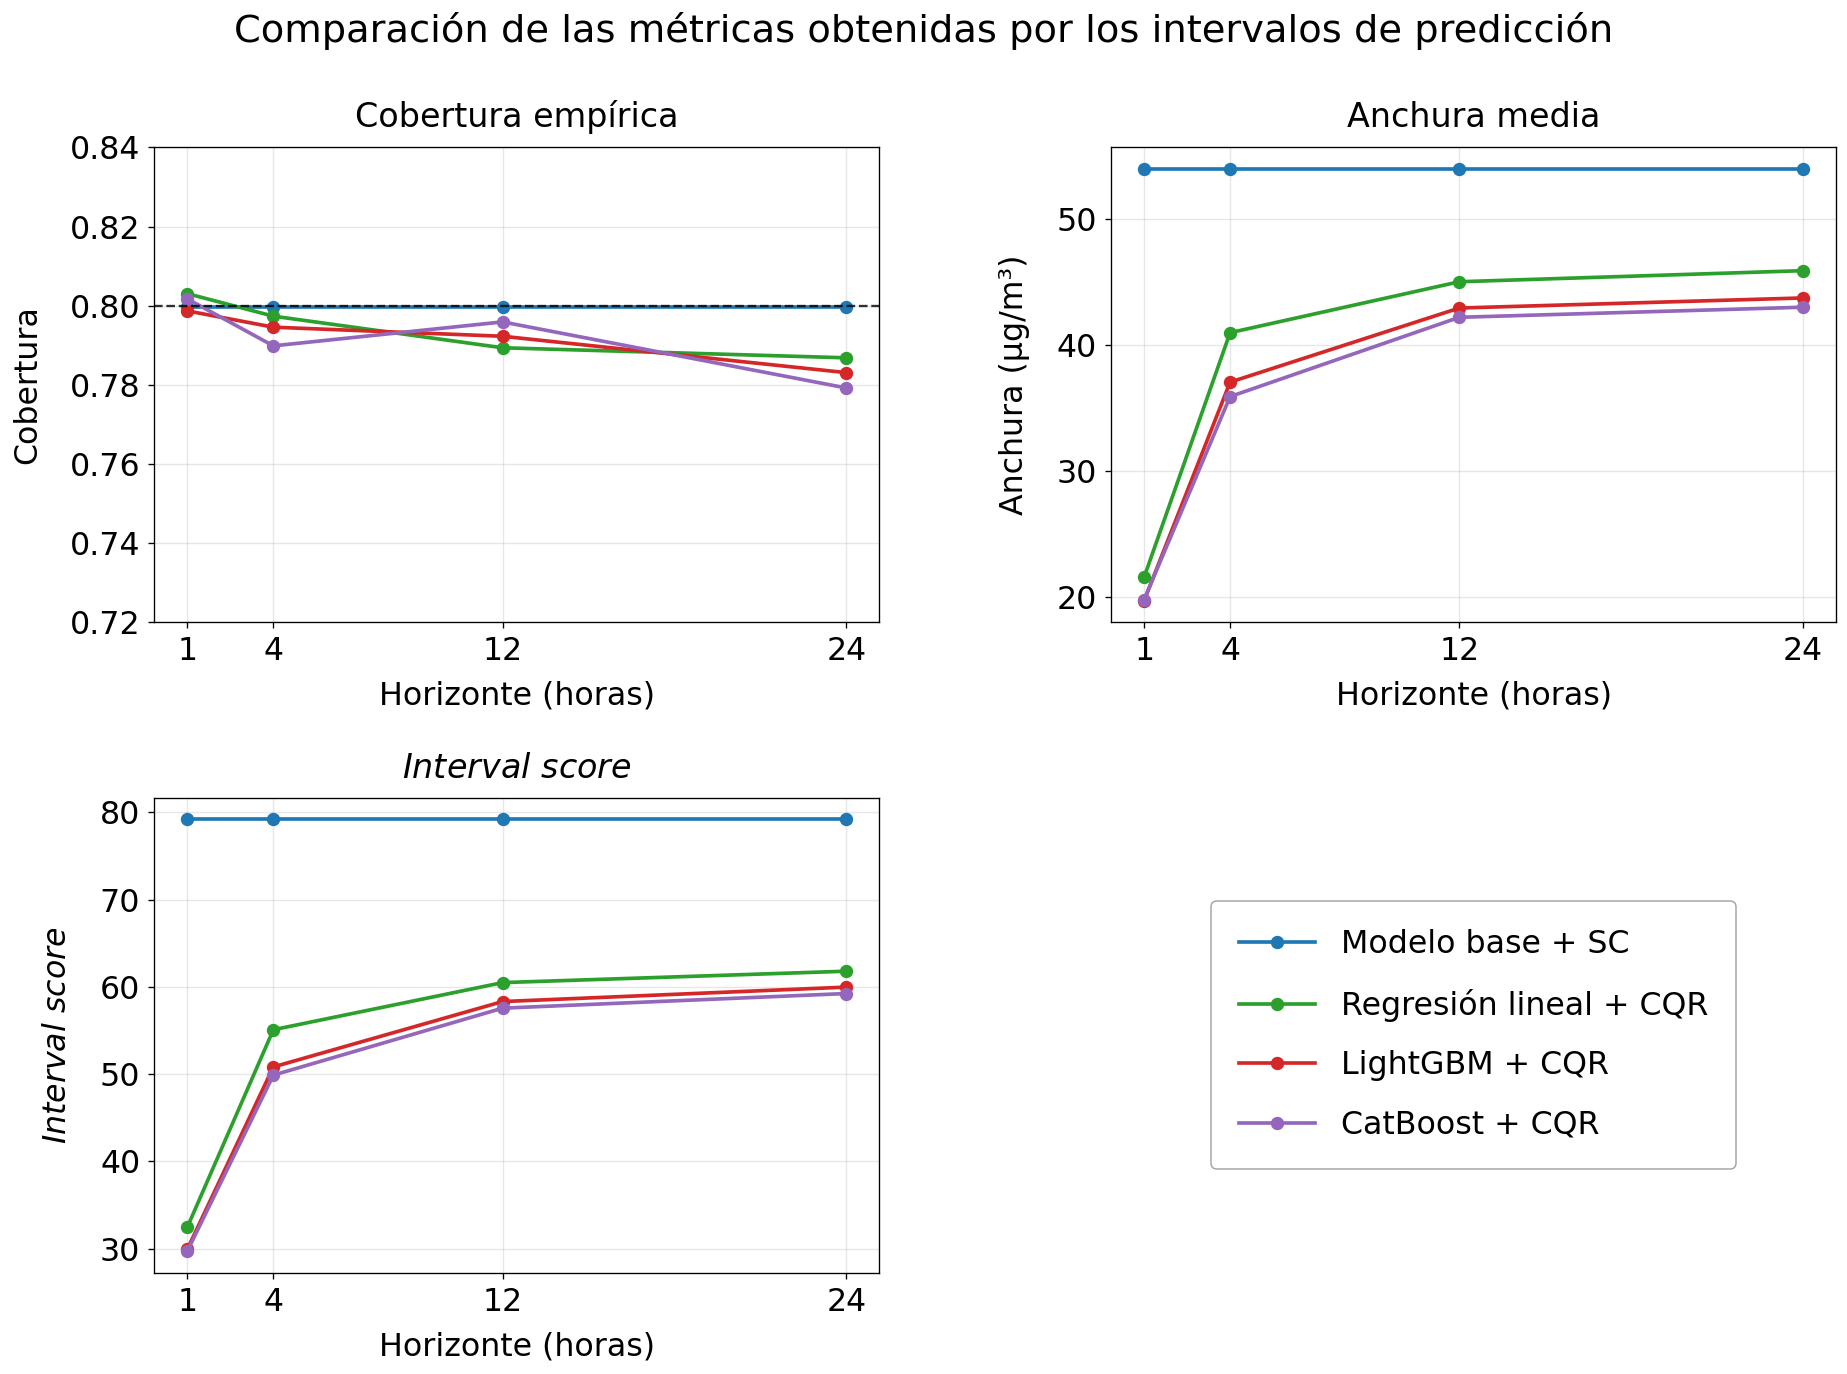

In [49]:
from matplotlib.lines import Line2D

# Tamaños de fuente
SUPTITLE_FS = 23
TITLE_FS = 20
LABEL_FS = 19
TICK_FS = 19
LEGEND_FS = 19

# Figura 2 x 2
# Aumento ligeramente la altura para que haya más aire entre filas.
fig, axes = plt.subplots(2, 2, figsize=(15.5, 12), sharex=False)

ax_cov = axes[0, 0]
ax_width = axes[0, 1]
ax_score = axes[1, 0]
ax_legend = axes[1, 1]

plot_df = common_metrics_df.copy()

metric_specs = [
    (
        ax_cov,
        "empirical_coverage",
        "Cobertura empírica",
        "Cobertura",
    ),
    (
        ax_width,
        "mean_width",
        "Anchura media",
        "Anchura (µg/m³)",
    ),
    (
        ax_score,
        "mean_interval_score",
        r"$\it{Interval\ score}$",
        r"$\it{Interval\ score}$",
    ),
]

# -------------------------------------------------------------------------
# Paneles con métricas
# -------------------------------------------------------------------------
for ax, metric, title, ylabel in metric_specs:
    for model_id in MODEL_ORDER:
        model_df = plot_df.loc[
            plot_df["model"] == model_id
        ].sort_values("horizon")

        meta = MODEL_REGISTRY[model_id]

        ax.plot(
            model_df["horizon"],
            model_df[metric],
            marker="o",
            linewidth=2.2,
            markersize=7,
            color=meta["color"],
            label=meta["label"],
        )

    # Primero aplico tu función de formato del eje horizontal
    configure_horizon_axis(ax)

    # Título del panel
    ax.set_title(
        title,
        fontsize=TITLE_FS,
        pad=12,
    )

    # Etiqueta vertical más separada de los ticks
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS,
        labelpad=16,
    )

    # Etiqueta horizontal en todos los paneles
    ax.set_xlabel(
        "Horizonte (horas)",
        fontsize=LABEL_FS,
        labelpad=8,
    )

    # Ticks del eje x en todos los paneles
    ax.set_xticks([1, 4, 12, 24])
    ax.set_xticklabels(["1", "4", "12", "24"])

    # Asegurar que los ticks del eje x sean visibles también en la fila superior
    ax.tick_params(
        axis="x",
        labelbottom=True,
        labelsize=TICK_FS,
        pad=5,
    )

    ax.tick_params(
        axis="y",
        labelsize=TICK_FS,
        pad=5,
    )

# -------------------------------------------------------------------------
# Línea horizontal de cobertura nominal
# -------------------------------------------------------------------------
ax_cov.axhline(
    NOMINAL_COVERAGE,
    linestyle="--",
    linewidth=1.4,
    color="black",
    alpha=0.8,
)

ax_cov.set_ylim(
    0.72,
    max(0.84, plot_df["empirical_coverage"].max() + 0.01),
)

# -------------------------------------------------------------------------
# Panel inferior derecho: leyenda enmarcada
# -------------------------------------------------------------------------
ax_legend.axis("off")

legend_handles = [
    Line2D(
        [0],
        [0],
        color=MODEL_REGISTRY[model_id]["color"],
        marker="o",
        linewidth=2.2,
        markersize=7,
        label=MODEL_REGISTRY[model_id]["label"],
    )
    for model_id in MODEL_ORDER
]

legend = ax_legend.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,
    fontsize=LEGEND_FS,
    frameon=True,
    framealpha=1.0,
    borderpad=0.9,
    labelspacing=0.9,
    handlelength=2.4,
    handletextpad=0.8,
)

legend.get_frame().set_linewidth(0.9)
legend.get_frame().set_edgecolor("0.65")

# -------------------------------------------------------------------------
# Título general
# -------------------------------------------------------------------------
fig.suptitle(
    "Comparación de las métricas obtenidas por los intervalos de predicción",
    y=0.95,
    fontsize=SUPTITLE_FS,
)

# -------------------------------------------------------------------------
# Ajustes de márgenes y separación entre paneles
# -------------------------------------------------------------------------
fig.tight_layout(rect=[0, 0, 1, 0.94])

fig.subplots_adjust(
    wspace=0.32,  # separación horizontal entre columnas
    hspace=0.37,  # separación vertical entre filas
)

figure_path = REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png"
save_figure(fig, figure_path)

plt.show()

Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_tradeoff_validation_common.png


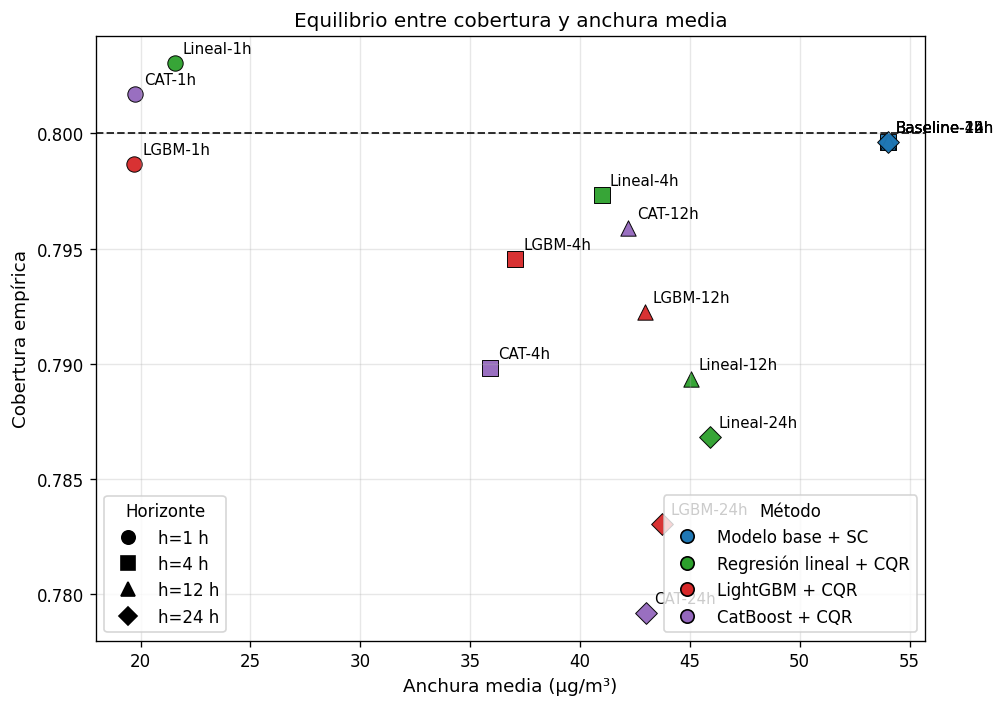

In [30]:

# Figura 2: equilibrio entre cobertura y anchura media

fig, ax = plt.subplots(figsize=(8.5, 6))
plot_df = common_metrics_df.copy()

for model_id in MODEL_ORDER:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    color = MODEL_REGISTRY[model_id]["color"]
    short_name = MODEL_REGISTRY[model_id]["short_name"]

    for _, row in model_df.iterrows():
        horizon = int(row["horizon"])
        marker = HORIZON_MARKERS[horizon]
        ax.scatter(
            row["mean_width"],
            row["empirical_coverage"],
            s=85,
            color=color,
            marker=marker,
            alpha=0.95,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.annotate(
            f"{short_name}-{horizon}h",
            xy=(row["mean_width"], row["empirical_coverage"]),
            xytext=(5, 6),
            textcoords="offset points",
            fontsize=9,
        )

ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.8)
ax.set_title("Equilibrio entre cobertura y anchura media")
ax.set_xlabel("Anchura media (µg/m³)")
ax.set_ylabel("Cobertura empírica")
ax.grid(True, alpha=0.3)

model_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=MODEL_REGISTRY[m]["label"],
        markerfacecolor=MODEL_REGISTRY[m]["color"],
        markeredgecolor="black",
        markersize=8,
    )
    for m in MODEL_ORDER
]

horizon_legend = [
    Line2D([0], [0], marker=HORIZON_MARKERS[h], color="black", linestyle="", label=f"h={h} h", markersize=8)
    for h in HORIZONS
]

legend1 = ax.legend(handles=model_legend, loc="lower right", frameon=True, title="Método")
ax.add_artist(legend1)
ax.legend(handles=horizon_legend, loc="lower left", frameon=True, title="Horizonte")

tradeoff_path = REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png"
fig.tight_layout()
save_figure(fig, tradeoff_path)
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_improvement_vs_baseline_validation_common.png


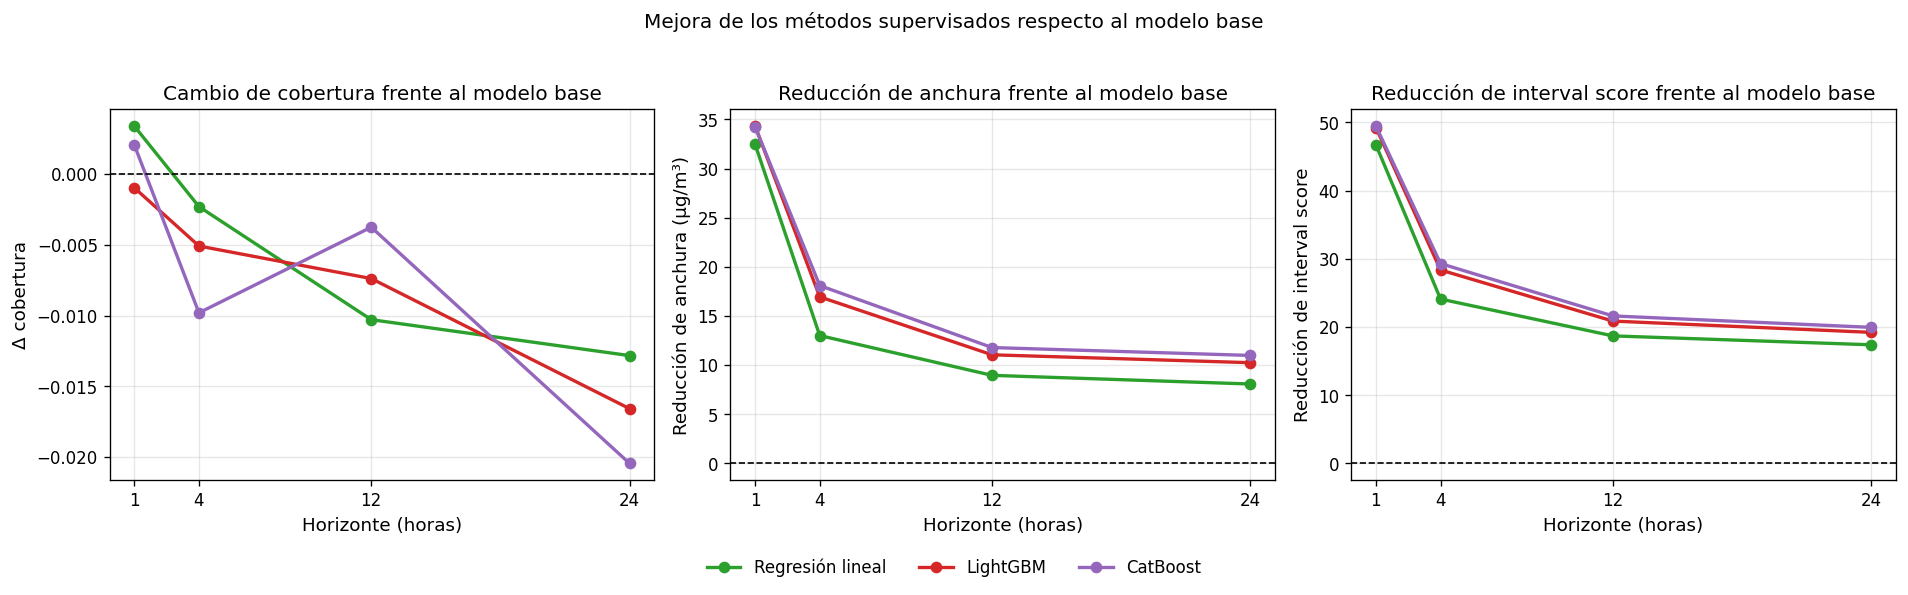

In [31]:

# Figura 3: mejora respecto al modelo base
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True)
plot_df = improvement_vs_baseline_df.copy()
non_baseline_models = [m for m in MODEL_ORDER if m != "baseline_seasonal_naive"]

improvement_specs = [
    ("delta_coverage_vs_baseline", "Cambio de cobertura frente al modelo base", "Δ cobertura"),
    ("width_reduction_vs_baseline", "Reducción de anchura frente al modelo base", "Reducción de anchura (µg/m³)"),
    ("interval_score_reduction_vs_baseline", "Reducción de interval score frente al modelo base", "Reducción de interval score"),
]

for ax, (metric, title, ylabel) in zip(axes, improvement_specs):
    for model_id in non_baseline_models:
        model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
        meta = MODEL_REGISTRY[model_id]

        ax.plot(
            model_df["horizon"],
            model_df[metric],
            marker="o",
            linewidth=2,
            color=meta["color"],
            label=meta["display_name"],
        )

    ax.axhline(0, linestyle="--", color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    configure_horizon_axis(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mejora de los métodos supervisados respecto al modelo base", y=1.03)
fig.tight_layout(rect=[0, 0.05, 1, 1])

improvement_fig_path = REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png"
save_figure(fig, improvement_fig_path)
plt.show()



### Figuras para la memoria

Para completar la comparación numérica, se ofrecen los siguientes ejemplo visuales.


In [32]:

# ==============================================================================
# Selección reproducible de un tramo para visualizar CatBoost cuantílico y CQR
# ==============================================================================

CATBOOST_MODEL_ID = "catboost"
CATBOOST_VISUAL_HORIZONS = [1, 4, 24]
CATBOOST_VISUAL_HOURS = 7 * 24  # 7 días

# Se priorizan episodios con concentración elevada de O3.
# 0.75 = tramos cuyo p90 observado está en el 25 % superior.
USE_HIGH_O3_FILTER = True
HIGH_O3_QUANTILE = 0.75

# Se escoge un tramo de dificultad intermedia según interval score calibrado.
# 0.50 = mediana. Si quieres un tramo algo más favorable, pero no extremo, usa 0.40.
TARGET_INTERVAL_SCORE_QUANTILE = 0.50

# Para que las fechas sean legibles, se prefieren tramos que empiecen a las 00:00.
PREFER_DAILY_STARTS = True

# Se usa el tramo visual maestro seleccionado previamente en el notebook 05.
# Esto garantiza que las figuras puntuales y de intervalos usen las mismas fechas.
USE_MASTER_VISUAL_WINDOW = True
VISUAL_MASTER_WINDOW_PATH = REPORTS_TABLES_DIR / "visual_master_selected_window.csv"

# Se usa common_intervals para mantener la lógica de comparación sobre instantes comunes.
SOURCE_INTERVALS = common_intervals.copy()
SOURCE_INTERVALS["target_timestamp"] = pd.to_datetime(SOURCE_INTERVALS["target_timestamp"])


def prepare_catboost_intervals_by_horizon(
    source_intervals: pd.DataFrame,
    horizons: Sequence[int],
) -> dict[int, pd.DataFrame]:
    """Normaliza columnas de CatBoost para las figuras de cuantiles y CQR."""
    intervals_by_horizon = {}

    for horizon in horizons:
        df_h = source_intervals.loc[
            (source_intervals["model"] == CATBOOST_MODEL_ID)
            & (source_intervals["horizon"] == horizon)
        ].copy()

        if df_h.empty:
            raise ValueError(f"No hay datos de CatBoost para h={horizon}.")

        df_h = df_h.sort_values("target_timestamp").reset_index(drop=True)

        central_col = first_existing_column(
            df_h,
            [
                "y_pred_quantile_median",
                "y_pred_reference",
                "y_pred_point",
                "y_pred",
                "y_pred_mapie",
                "median",
                "pred_median",
            ],
            purpose=f"predicción central / mediana en h={horizon}",
        )

        prelim_lower_col = first_existing_column(
            df_h,
            [
                "lower_prelim",
                "y_pred_quantile_lower",
                "y_pred_lower",
                "quantile_lower",
                "lower_quantile",
                "q_lower",
            ],
            purpose=f"cuantil inferior preliminar en h={horizon}",
        )

        prelim_upper_col = first_existing_column(
            df_h,
            [
                "upper_prelim",
                "y_pred_quantile_upper",
                "y_pred_upper",
                "quantile_upper",
                "upper_quantile",
                "q_upper",
            ],
            purpose=f"cuantil superior preliminar en h={horizon}",
        )

        required_cols = ["target_timestamp", "y_true", "lower", "upper", "interval_score"]
        missing_cols = [col for col in required_cols if col not in df_h.columns]
        if missing_cols:
            raise KeyError(f"Faltan columnas necesarias para CatBoost h={horizon}: {missing_cols}")

        # Columnas normalizadas para que las figuras sean independientes de los nombres originales.
        df_h = df_h.assign(
            central_pred=df_h[central_col],
            prelim_lower=df_h[prelim_lower_col],
            prelim_upper=df_h[prelim_upper_col],
            calibrated_lower=df_h["lower"],
            calibrated_upper=df_h["upper"],
        )

        intervals_by_horizon[horizon] = df_h

        print(
            f"h={horizon}: columna central = {central_col}, "
            f"cuantil inferior = {prelim_lower_col}, "
            f"cuantil superior = {prelim_upper_col}"
        )

    return intervals_by_horizon


def evaluate_catboost_visual_windows(
    intervals_by_horizon: dict[int, pd.DataFrame],
    candidate_windows: Sequence[dict[str, Any]],
) -> pd.DataFrame:
    """Evalúa cada tramo candidato con métricas preliminares y calibradas."""
    candidate_rows = []

    for window_idx, candidate_window in enumerate(candidate_windows):
        candidate_targets = set(candidate_window["target_timestamps"])
        observed_values = None

        calibrated_scores = []
        calibrated_widths = []
        calibrated_coverages = []

        prelim_scores = []
        prelim_widths = []
        prelim_coverages = []

        central_abs_errors = []
        valid_window = True

        for horizon in CATBOOST_VISUAL_HORIZONS:
            df_h = intervals_by_horizon[horizon]
            block_h = df_h.loc[df_h["target_timestamp"].isin(candidate_targets)].copy()
            block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)

            if len(block_h) != CATBOOST_VISUAL_HOURS:
                valid_window = False
                break

            if observed_values is None:
                observed_values = block_h["y_true"].to_numpy()

            # Intervalos calibrados mediante CQR.
            calibrated_scores.append(block_h["interval_score"].to_numpy())
            calibrated_widths.append((block_h["calibrated_upper"] - block_h["calibrated_lower"]).to_numpy())
            calibrated_coverages.append(
                (
                    (block_h["y_true"] >= block_h["calibrated_lower"])
                    & (block_h["y_true"] <= block_h["calibrated_upper"])
                ).to_numpy()
            )

            # Intervalos cuantílicos preliminares.
            prelim_score_h = interval_score(
                block_h["y_true"],
                block_h["prelim_lower"],
                block_h["prelim_upper"],
                ALPHA,
            )
            prelim_scores.append(prelim_score_h)
            prelim_widths.append((block_h["prelim_upper"] - block_h["prelim_lower"]).to_numpy())
            prelim_coverages.append(
                (
                    (block_h["y_true"] >= block_h["prelim_lower"])
                    & (block_h["y_true"] <= block_h["prelim_upper"])
                ).to_numpy()
            )

            # Error absoluto de la predicción central.
            central_abs_errors.append(np.abs(block_h["y_true"].to_numpy() - block_h["central_pred"].to_numpy()))

        if not valid_window or observed_values is None:
            continue

        calibrated_scores = np.concatenate(calibrated_scores)
        calibrated_widths = np.concatenate(calibrated_widths)
        calibrated_coverages = np.concatenate(calibrated_coverages)

        prelim_scores = np.concatenate(prelim_scores)
        prelim_widths = np.concatenate(prelim_widths)
        prelim_coverages = np.concatenate(prelim_coverages)

        central_abs_errors = np.concatenate(central_abs_errors)

        candidate_rows.append(
            {
                "window_idx": window_idx,
                "start": candidate_window["start"],
                "end": candidate_window["end"],
                "n_hours": CATBOOST_VISUAL_HOURS,
                "observed_mean": float(np.mean(observed_values)),
                "observed_p90": float(np.quantile(observed_values, 0.90)),
                "observed_max": float(np.max(observed_values)),
                "central_mae": float(np.mean(central_abs_errors)),
                "prelim_coverage": float(np.mean(prelim_coverages)),
                "prelim_mean_width": float(np.mean(prelim_widths)),
                "prelim_mean_interval_score": float(np.mean(prelim_scores)),
                "calibrated_coverage": float(np.mean(calibrated_coverages)),
                "calibrated_mean_width": float(np.mean(calibrated_widths)),
                "calibrated_mean_interval_score": float(np.mean(calibrated_scores)),
            }
        )

    candidate_windows_df = pd.DataFrame(candidate_rows)

    if candidate_windows_df.empty:
        raise ValueError("No se pudo evaluar ningún tramo candidato válido.")

    return candidate_windows_df


# ------------------------------------------------------------------------------
# 1. DataFrames de CatBoost por horizonte
# ------------------------------------------------------------------------------
catboost_intervals_by_horizon = prepare_catboost_intervals_by_horizon(
    SOURCE_INTERVALS,
    CATBOOST_VISUAL_HORIZONS,
)

# ------------------------------------------------------------------------------
# 2. Timestamps comunes a h=1, h=4 y h=24
# ------------------------------------------------------------------------------
common_targets_across_horizons = set.intersection(
    *[
        set(pd.DatetimeIndex(df_h["target_timestamp"]))
        for df_h in catboost_intervals_by_horizon.values()
    ]
)

common_targets_df = (
    pd.DataFrame({"target_timestamp": sorted(common_targets_across_horizons)})
    .sort_values("target_timestamp")
    .reset_index(drop=True)
)

if common_targets_df.empty:
    raise ValueError("No hay timestamps comunes para los horizontes seleccionados.")

candidate_windows = find_candidate_continuous_windows(
    timestamps=common_targets_df["target_timestamp"],
    n_hours=CATBOOST_VISUAL_HOURS,
    prefer_daily_starts=PREFER_DAILY_STARTS,
)

if not candidate_windows:
    raise ValueError(
        f"No se encontraron tramos continuos de {CATBOOST_VISUAL_HOURS} horas "
        f"comunes a los horizontes {CATBOOST_VISUAL_HORIZONS}."
    )

print(f"Tramos candidatos encontrados: {len(candidate_windows)}")

# ------------------------------------------------------------------------------
# 3. Evaluación de tramos candidatos
# ------------------------------------------------------------------------------
candidate_windows_df = evaluate_catboost_visual_windows(
    catboost_intervals_by_horizon,
    candidate_windows,
)

candidate_table_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_candidate_windows.csv"
save_dataframe_csv(candidate_windows_df, candidate_table_path, index=False)

# ------------------------------------------------------------------------------
# 4. Selección reproducible del tramo
# ------------------------------------------------------------------------------
if USE_HIGH_O3_FILTER:
    high_o3_threshold = candidate_windows_df["observed_p90"].quantile(HIGH_O3_QUANTILE)
    candidate_windows_df["passes_high_o3_filter"] = candidate_windows_df["observed_p90"] >= high_o3_threshold
    selectable_windows_df = candidate_windows_df.loc[candidate_windows_df["passes_high_o3_filter"]].copy()

    print(
        "Filtro de alta concentración activado:",
        f"p90 observado >= {high_o3_threshold:.2f} µg/m³",
        f"({len(selectable_windows_df)} tramos elegibles)",
    )
else:
    high_o3_threshold = np.nan
    candidate_windows_df["passes_high_o3_filter"] = True
    selectable_windows_df = candidate_windows_df.copy()

    print(
        "Filtro de alta concentración desactivado:",
        f"{len(selectable_windows_df)} tramos elegibles",
    )

if selectable_windows_df.empty:
    raise ValueError("No quedan tramos elegibles tras aplicar el filtro de concentración.")

target_interval_score = selectable_windows_df["calibrated_mean_interval_score"].quantile(
    TARGET_INTERVAL_SCORE_QUANTILE
)

candidate_windows_df["distance_to_target_interval_score"] = (
    candidate_windows_df["calibrated_mean_interval_score"] - target_interval_score
).abs()
candidate_windows_df["coverage_abs_error"] = (
    candidate_windows_df["calibrated_coverage"] - NOMINAL_COVERAGE
).abs()
selectable_windows_df = candidate_windows_df.loc[candidate_windows_df["passes_high_o3_filter"]].copy()

# Se vuelve a guardar la tabla de candidatos con las columnas de selección añadidas.
save_dataframe_csv(candidate_windows_df, candidate_table_path, index=False)

if USE_MASTER_VISUAL_WINDOW:
    if not VISUAL_MASTER_WINDOW_PATH.exists():
        raise FileNotFoundError(
            f"No se encontró el tramo visual maestro en {VISUAL_MASTER_WINDOW_PATH}. "
            "Ejecuta primero el notebook 05 actualizado, que debe guardar "
            "visual_master_selected_window.csv."
        )

    master_window_df = pd.read_csv(VISUAL_MASTER_WINDOW_PATH)
    master_start_ts = pd.Timestamp(master_window_df.loc[0, "start"])
    master_end_ts = pd.Timestamp(master_window_df.loc[0, "end"])

    matched_windows_df = candidate_windows_df.loc[
        (pd.to_datetime(candidate_windows_df["start"]) == master_start_ts)
        & (pd.to_datetime(candidate_windows_df["end"]) == master_end_ts)
    ].copy()

    if matched_windows_df.empty:
        raise ValueError(
            "El tramo maestro seleccionado en el notebook 05 no está disponible "
            "como tramo continuo válido en el notebook 07.\n"
            f"Tramo maestro: {master_start_ts} → {master_end_ts}\n"
            "Revisa que los horizontes, la longitud del tramo y los timestamps comunes "
            "coincidan entre notebooks."
        )

    selected_window = matched_windows_df.iloc[0]

    print("\nTramo visual maestro cargado desde el notebook 05:")
    print(f"Inicio: {master_start_ts}")
    print(f"Fin: {master_end_ts}")
    print(
        "Supera el filtro de alta concentración del notebook 07:",
        bool(selected_window["passes_high_o3_filter"]),
    )
else:
    # Criterio final:
    # 1) interval score medio calibrado cercano al cuantil objetivo;
    # 2) cobertura del tramo más cercana a la nominal;
    # 3) mayor p90 observado;
    # 4) orden cronológico.
    selected_window = (
        selectable_windows_df
        .sort_values(
            [
                "distance_to_target_interval_score",
                "coverage_abs_error",
                "observed_p90",
                "start",
            ],
            ascending=[True, True, False, True],
        )
        .iloc[0]
    )

CATBOOST_VISUAL_START_TS = pd.Timestamp(selected_window["start"])
CATBOOST_VISUAL_END_TS = pd.Timestamp(selected_window["end"])
selected_visual_targets = set(
    pd.date_range(start=CATBOOST_VISUAL_START_TS, end=CATBOOST_VISUAL_END_TS, freq="h")
)

print("\nTramo seleccionado de forma reproducible:")
print(f"Inicio: {CATBOOST_VISUAL_START_TS}")
print(f"Fin: {CATBOOST_VISUAL_END_TS}")
print(f"Horas: {CATBOOST_VISUAL_HOURS}")
print(f"Media observada O3: {selected_window['observed_mean']:.2f} µg/m³")
print(f"p90 observado O3: {selected_window['observed_p90']:.2f} µg/m³")
print(f"Máximo observado O3: {selected_window['observed_max']:.2f} µg/m³")
print(f"MAE central medio: {selected_window['central_mae']:.2f}")
print(f"Cobertura preliminar del tramo: {selected_window['prelim_coverage']:.3f}")
print(f"Cobertura calibrada del tramo: {selected_window['calibrated_coverage']:.3f}")
print(f"Anchura media calibrada: {selected_window['calibrated_mean_width']:.2f}")
print(f"Interval score preliminar medio: {selected_window['prelim_mean_interval_score']:.2f}")
print(f"Interval score calibrado medio: {selected_window['calibrated_mean_interval_score']:.2f}")
print(f"Interval score objetivo: {target_interval_score:.2f}")

# ------------------------------------------------------------------------------
# 5. Bloques finales por horizonte para las figuras
# ------------------------------------------------------------------------------
catboost_visual_blocks_by_horizon = {}

for horizon in CATBOOST_VISUAL_HORIZONS:
    df_h = catboost_intervals_by_horizon[horizon]
    block_h = df_h.loc[df_h["target_timestamp"].isin(selected_visual_targets)].copy()
    block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)

    if len(block_h) != CATBOOST_VISUAL_HOURS:
        raise ValueError(
            f"El bloque seleccionado para h={horizon} tiene {len(block_h)} filas, "
            f"pero se esperaban {CATBOOST_VISUAL_HOURS}."
        )

    catboost_visual_blocks_by_horizon[horizon] = block_h

    print(
        f"h={horizon}: "
        f"{block_h['target_timestamp'].min()} → {block_h['target_timestamp'].max()} "
        f"({len(block_h)} observaciones)"
    )

selected_window_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_selected_window.csv"
save_dataframe_csv(selected_window.to_frame().T, selected_window_path, index=False)


h=1: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
h=4: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
h=24: columna central = y_pred_quantile_median, cuantil inferior = lower_prelim, cuantil superior = upper_prelim
Tramos candidatos encontrados: 129
Tabla guardada: c:\trabajo_github\reports\tables\catboost_cqr_visual_candidate_windows.csv
Filtro de alta concentración activado: p90 observado >= 86.00 µg/m³ (34 tramos elegibles)
Tabla guardada: c:\trabajo_github\reports\tables\catboost_cqr_visual_candidate_windows.csv

Tramo visual maestro cargado desde el notebook 05:
Inicio: 2024-06-25 00:00:00
Fin: 2024-07-01 23:00:00
Supera el filtro de alta concentración del notebook 07: True

Tramo seleccionado de forma reproducible:
Inicio: 2024-06-25 00:00:00
Fin: 2024-07-01 23:00:00
Horas: 168
Media observada O3: 58.93 µg/m³
p90 observado O3: 86.00 µg/m³
Máximo observado O3: 

WindowsPath('c:/trabajo_github/reports/tables/catboost_cqr_visual_selected_window.csv')

Fuente usada para el modelo base: common_intervals
Tramo visual: 2024-06-25 00:00:00 → 2024-07-01 23:00:00
Filas detectadas como modelo base: 33060
Valores detectados en 'model': ['baseline_seasonal_naive']
Valores detectados en 'label': ['Modelo base + SC']
Valores detectados en 'method': ['split_conformal']

q_hat ≈ 27.000 µg/m³
Anchura ≈ 54.000 µg/m³
Tramo del modelo base: 2024-06-25 00:00:00 → 2024-07-01 23:00:00 (168 observaciones)
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_selected_window_all_horizons.csv
Figura guardada en: c:\trabajo_github\reports\figures\fig_split_conformal_baseline_selected_window_all_horizons.png
Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_zoom_best_vs_baseline_h24.png


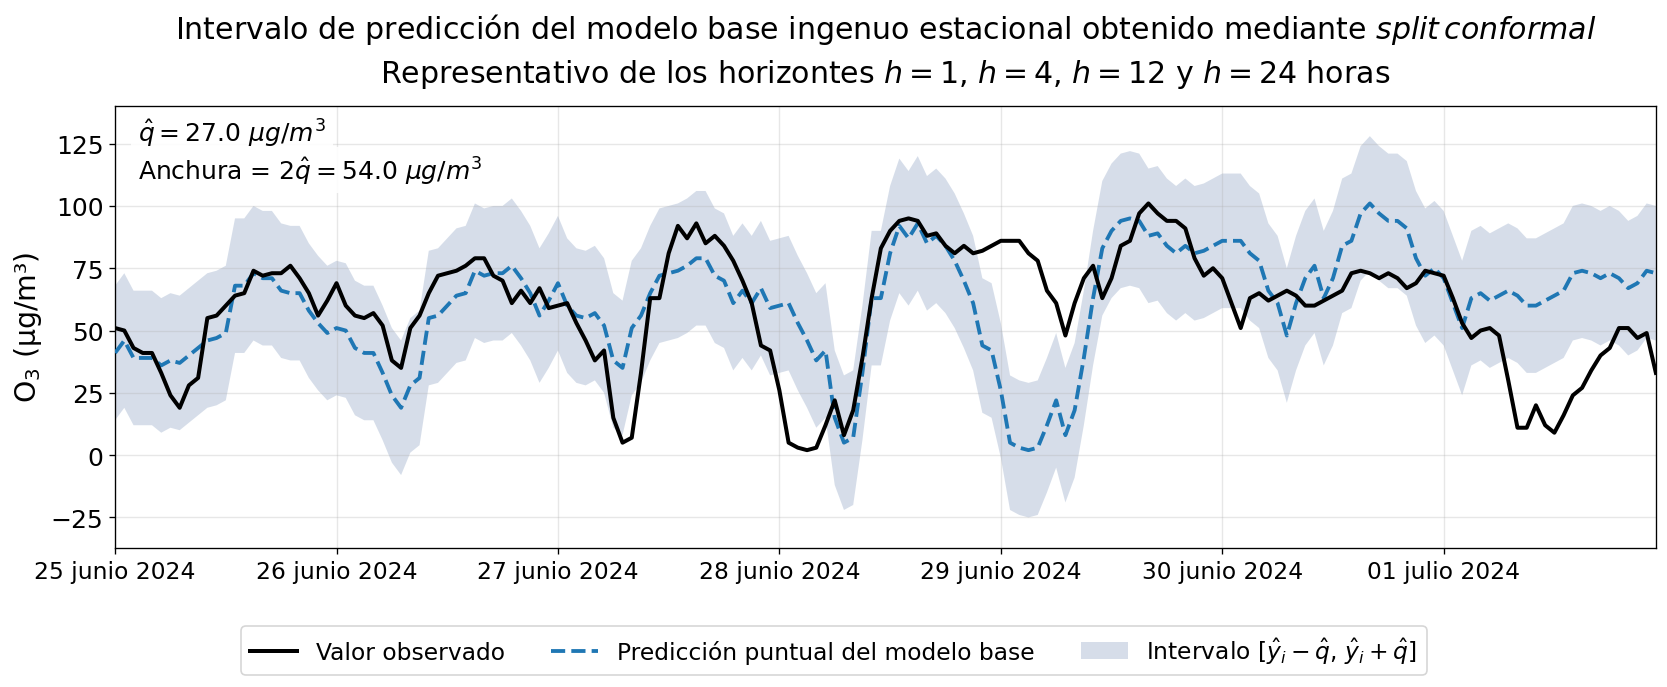

In [33]:

# ==============================================================================
# Figura: intervalo de predicción del modelo base con split conformal
# - usa el mismo tramo seleccionado para CatBoost/CQR
# - representativa de todos los horizontes
# - leyenda debajo
# - meses en letras y minúscula
# ==============================================================================

# ------------------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------------------
# Aunque el intervalo del modelo base es idéntico para todos los horizontes,
# se toma uno de ellos para extraer las filas.
BASELINE_VISUAL_HORIZON = 24

# Si existe baseline_intervals en memoria, se usará directamente.
# En caso contrario, se intentará recuperar el modelo base desde common_intervals.
SOURCE_BASELINE_INTERVALS = common_intervals.copy()
SOURCE_NAME = "common_intervals"
SOURCE_BASELINE_INTERVALS["target_timestamp"] = pd.to_datetime(SOURCE_BASELINE_INTERVALS["target_timestamp"])

# Se reutiliza el tramo ya seleccionado en la celda de CatBoost/CQR.
if "CATBOOST_VISUAL_START_TS" not in globals() or "CATBOOST_VISUAL_END_TS" not in globals():
    selected_window_path = REPORTS_TABLES_DIR / "catboost_cqr_visual_selected_window.csv"

    if selected_window_path.exists():
        selected_window_df = pd.read_csv(selected_window_path)
        VISUAL_START_TS = pd.Timestamp(selected_window_df.loc[0, "start"])
        VISUAL_END_TS = pd.Timestamp(selected_window_df.loc[0, "end"])
    else:
        raise ValueError(
            "No se encontraron CATBOOST_VISUAL_START_TS y CATBOOST_VISUAL_END_TS, "
            "ni el archivo catboost_cqr_visual_selected_window.csv. "
            "Ejecuta primero la celda de selección reproducible del tramo."
        )
else:
    VISUAL_START_TS = pd.Timestamp(CATBOOST_VISUAL_START_TS)
    VISUAL_END_TS = pd.Timestamp(CATBOOST_VISUAL_END_TS)

print(f"Fuente usada para el modelo base: {SOURCE_NAME}")
print(f"Tramo visual: {VISUAL_START_TS} → {VISUAL_END_TS}")

# ------------------------------------------------------------------------------
# 1. Localización del modelo base y selección del bloque
# ------------------------------------------------------------------------------
baseline_mask = detect_baseline_mask(SOURCE_BASELINE_INTERVALS)

if "horizon" not in SOURCE_BASELINE_INTERVALS.columns:
    raise KeyError("La fuente de intervalos no contiene la columna 'horizon'.")

# Conversión robusta del horizonte por si aparece como texto.
SOURCE_BASELINE_INTERVALS["_horizon_num"] = pd.to_numeric(
    SOURCE_BASELINE_INTERVALS["horizon"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)

df_base = SOURCE_BASELINE_INTERVALS.loc[
    baseline_mask
    & (SOURCE_BASELINE_INTERVALS["_horizon_num"] == BASELINE_VISUAL_HORIZON)
].copy()

if df_base.empty:
    available_horizons = (
        SOURCE_BASELINE_INTERVALS.loc[baseline_mask, "_horizon_num"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
    raise ValueError(
        f"No hay datos del modelo base para h={BASELINE_VISUAL_HORIZON}. "
        f"Horizontes disponibles para el modelo base: {available_horizons}"
    )

df_base = df_base.sort_values("target_timestamp").reset_index(drop=True)

pred_col = first_existing_column(
    df_base,
    ["y_pred", "y_pred_point", "y_pred_reference", "y_pred_baseline", "prediction", "pred", "y_hat"],
    purpose="predicción puntual del modelo base",
)

required_cols = ["target_timestamp", "y_true", "lower", "upper"]
missing_cols = [col for col in required_cols if col not in df_base.columns]
if missing_cols:
    raise KeyError(f"Faltan columnas necesarias en el modelo base: {missing_cols}")

example_block = df_base.loc[
    (df_base["target_timestamp"] >= VISUAL_START_TS)
    & (df_base["target_timestamp"] <= VISUAL_END_TS)
].copy()
example_block = example_block.sort_values("target_timestamp").reset_index(drop=True)

if example_block.empty:
    raise ValueError("El tramo seleccionado no contiene observaciones del modelo base.")

expected_hours = int((VISUAL_END_TS - VISUAL_START_TS) / pd.Timedelta(hours=1)) + 1
if len(example_block) != expected_hours:
    print(
        f"Advertencia: el tramo contiene {len(example_block)} observaciones, "
        f"pero se esperaban {expected_hours}. Revisa si faltan timestamps."
    )

# ------------------------------------------------------------------------------
# 2. Columnas normalizadas y parámetros del intervalo
# ------------------------------------------------------------------------------
example_block["point_pred"] = example_block[pred_col]
example_block["interval_lower"] = example_block["lower"]
example_block["interval_upper"] = example_block["upper"]

# Cuantil conforme estimado a partir de la semianchura del intervalo.
q_hat_series = 0.5 * (example_block["interval_upper"] - example_block["interval_lower"])
q_hat = float(np.nanmedian(q_hat_series))
interval_width = 2.0 * q_hat

print(f"\nq_hat ≈ {q_hat:.3f} µg/m³")
print(f"Anchura ≈ {interval_width:.3f} µg/m³")
print(
    "Tramo del modelo base:",
    example_block["target_timestamp"].min(),
    "→",
    example_block["target_timestamp"].max(),
    f"({len(example_block)} observaciones)",
)

# ------------------------------------------------------------------------------
# 3. Guardado del bloque visual
# ------------------------------------------------------------------------------
example_block_path = REPORTS_TABLES_DIR / "split_conformal_baseline_selected_window_all_horizons.csv"
save_dataframe_csv(example_block, example_block_path, index=False)

# ------------------------------------------------------------------------------
# 4. Estilo
# ------------------------------------------------------------------------------
observed_color = "black"
prediction_color = "#1f77b4"
interval_color = "#cfd8e6"

# ------------------------------------------------------------------------------
# 5. Figura
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6.8))

# Banda del intervalo.
ax.fill_between(
    example_block["target_timestamp"],
    example_block["interval_lower"],
    example_block["interval_upper"],
    color=interval_color,
    alpha=0.85,
    edgecolor="none",
    linewidth=0,
    zorder=1,
)

# Valor observado.
ax.plot(
    example_block["target_timestamp"],
    example_block["y_true"],
    color=observed_color,
    linewidth=2.4,
    label="Valor observado",
    zorder=4,
)

# Predicción puntual.
ax.plot(
    example_block["target_timestamp"],
    example_block["point_pred"],
    color=prediction_color,
    linewidth=2.3,
    linestyle="--",
    label="Predicción puntual del modelo base",
    zorder=3,
)

# Texto informativo.
ax.text(
    0.015,
    0.92,
    rf"$\hat{{q}} = {q_hat:.1f}\ \mu g/m^3$",
    transform=ax.transAxes,
    fontsize=15,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.90, pad=4),
)
ax.text(
    0.015,
    0.835,
    rf"Anchura = $2\hat{{q}} = {interval_width:.1f}\ \mu g/m^3$",
    transform=ax.transAxes,
    fontsize=15,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.90, pad=4),
)

# ------------------------------------------------------------------------------
# 6. Formato general
# ------------------------------------------------------------------------------
ax.set_title(
    r"Intervalo de predicción del modelo base ingenuo estacional obtenido mediante $split\, conformal$"
    "\n"
    r"Representativo de los horizontes $h=1$, $h=4$, $h=12$ y $h=24$ horas",
    fontsize=18,
    linespacing=1.45,
    pad=14,
)
ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=17)
# ax.set_xlabel("Fecha objetivo", fontsize=15)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", labelsize=15)
ax.margins(x=0.01, y=0.08)
ax.set_xlim(VISUAL_START_TS, VISUAL_END_TS)

# ------------------------------------------------------------------------------
# 7. Fechas
# ------------------------------------------------------------------------------
tick_dates = pd.date_range(
    start=VISUAL_START_TS.normalize(),
    end=VISUAL_END_TS.normalize(),
    freq="1D",
)
configure_spanish_date_axis(ax, tick_dates=tick_dates, labelsize=14)

# ------------------------------------------------------------------------------
# 8. Leyenda debajo
# ------------------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=observed_color, linewidth=2.4, label="Valor observado"),
    Line2D(
        [0],
        [0],
        color=prediction_color,
        linewidth=2.3,
        linestyle="--",
        label="Predicción puntual del modelo base",
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.85,
        label=r"Intervalo $[\hat{y}_i-\hat{q},\,\hat{y}_i+\hat{q}]$",
    ),
]
legend = fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    fontsize=14,
    frameon=True,
)

# ------------------------------------------------------------------------------
# 10. Guardado
# ------------------------------------------------------------------------------
fig.tight_layout(rect=(0, 0.10, 1, 0.88))
fig.subplots_adjust(bottom=0.20)

interval_zoom_path = REPORTS_FIGURES_DIR / "fig_split_conformal_baseline_selected_window_all_horizons.png"
legacy_interval_zoom_path = REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png"
save_figure(
    fig,
    interval_zoom_path,
    aliases=[legacy_interval_zoom_path],
    bbox_extra_artists=(legend,),
)
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_quantiles_prelim_h01_h04_h24.png


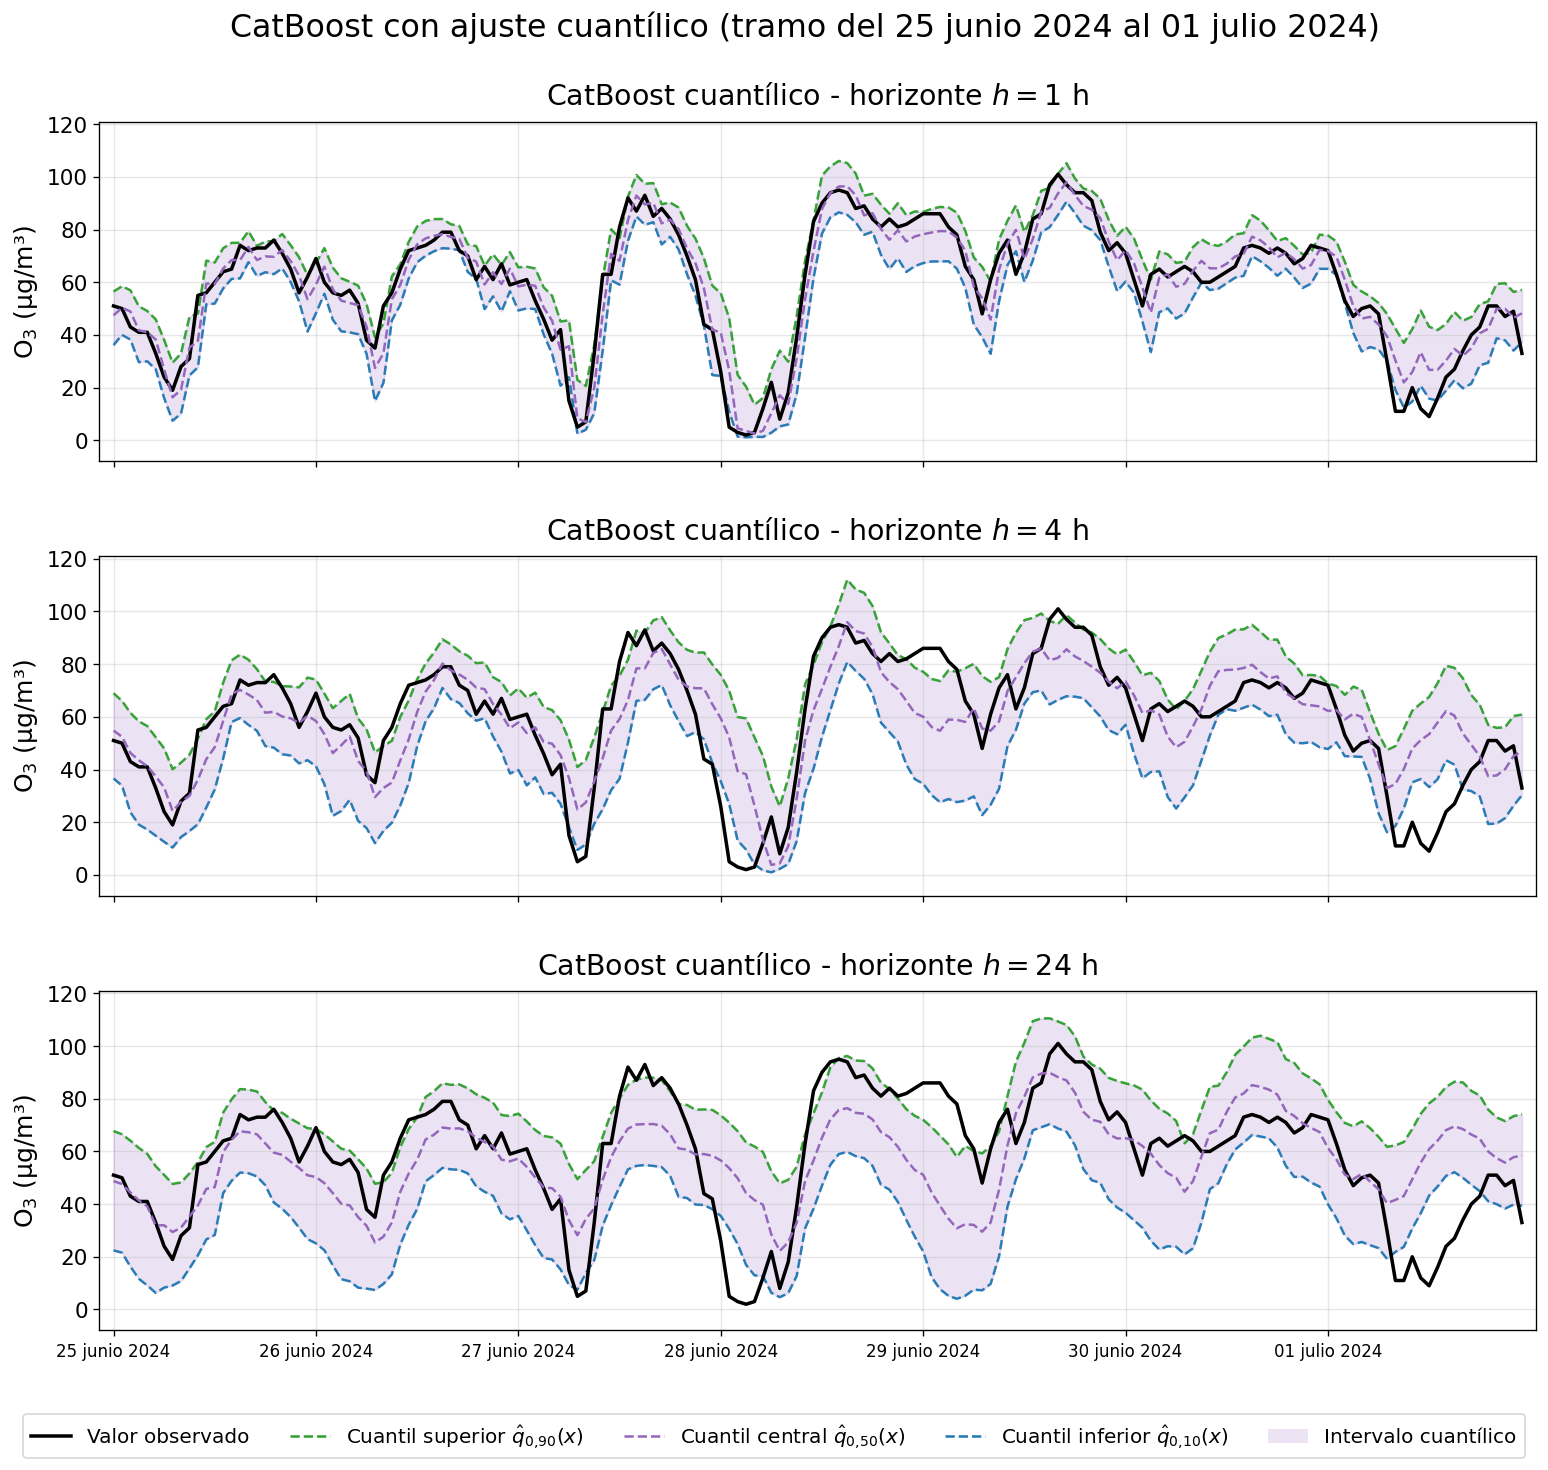

In [34]:

# ==============================================================================
# Figura: cuantiles preliminares de CatBoost con formato vertical
# - colores distintos por cuantil
# - mayor tamaño vertical por panel
# - fechas con el mes en letras
# ==============================================================================

# ------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------
CATBOOST_VISUAL_HORIZONS = [1, 4, 24]
lower_quantile_label = format_quantile_label(ALPHA / 2)
upper_quantile_label = format_quantile_label(1 - ALPHA / 2)

observed_color = "black"
central_color = MODEL_REGISTRY[CATBOOST_MODEL_ID]["color"]   # color CatBoost
lower_color = "#1f77b4"   # azul
upper_color = "#2ca02c"   # verde
band_color = "#9467bd"    # morado suave para la banda

# ------------------------------------------------------------------
# Rango vertical común para todos los paneles
# ------------------------------------------------------------------
common_ylim = common_ylim_from_blocks(
    [
        block
        for horizon, block in catboost_visual_blocks_by_horizon.items()
        if horizon in CATBOOST_VISUAL_HORIZONS
    ],
    ["y_true", "central_pred", "prelim_lower", "prelim_upper"],
)

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
panel_height = 4.25
fig, axes = plt.subplots(
    len(CATBOOST_VISUAL_HORIZONS),
    1,
    figsize=(13, panel_height * len(CATBOOST_VISUAL_HORIZONS)),
    sharex=True,
    sharey=True,
)

if len(CATBOOST_VISUAL_HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, CATBOOST_VISUAL_HORIZONS):
    block = catboost_visual_blocks_by_horizon[horizon]

    # Banda del intervalo cuantílico preliminar.
    ax.fill_between(
        block["target_timestamp"],
        block["prelim_lower"],
        block["prelim_upper"],
        color=band_color,
        alpha=0.18,
        zorder=1,
    )

    # Valor observado.
    ax.plot(block["target_timestamp"], block["y_true"], color=observed_color, linewidth=2.1, zorder=4)

    # Cuantil inferior.
    ax.plot(
        block["target_timestamp"],
        block["prelim_lower"],
        color=lower_color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.95,
        zorder=3,
    )

    # Cuantil central.
    ax.plot(
        block["target_timestamp"],
        block["central_pred"],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        zorder=5,
    )

    # Cuantil superior.
    ax.plot(
        block["target_timestamp"],
        block["prelim_upper"],
        color=upper_color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.95,
        zorder=3,
    )

    ax.set_title(rf"CatBoost cuantílico - horizonte $h={horizon}$ h", fontsize=17, pad=10)
    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=15)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=13)
    ax.margins(x=0.01, y=0.06)

# axes[-1].set_xlabel("Fecha objetivo", fontsize=12)

# ------------------------------------------------------------------
# Formato de fechas: marcas cada día y mes en letras
# ------------------------------------------------------------------
TICK_EVERY_N_DAYS = 1
axis_start = min(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).min()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()
axis_end = max(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).max()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()
tick_dates = pd.date_range(start=axis_start, end=axis_end, freq=f"{TICK_EVERY_N_DAYS}D")

for ax in axes:
    configure_spanish_date_axis(ax, tick_dates=tick_dates)

# ------------------------------------------------------------------
# Leyenda
# ------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=observed_color, linewidth=2.1, label="Valor observado"),
    Line2D(
        [0],
        [0],
        color=upper_color,
        linewidth=1.5,
        linestyle="--",
        label=rf"Cuantil superior $\hat{{q}}_{{{upper_quantile_label}}}(x)$",
    ),
    Line2D(
        [0],
        [0],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        label=r"Cuantil central $\hat{q}_{0{,}50}(x)$",
    ),
    Line2D(
        [0],
        [0],
        color=lower_color,
        linewidth=1.5,
        linestyle="--",
        label=rf"Cuantil inferior $\hat{{q}}_{{{lower_quantile_label}}}(x)$",
    ),
    Patch(facecolor=band_color, alpha=0.18, label="Intervalo cuantílico"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=5,
    fontsize=12,
    frameon=True,
)

# ------------------------------------------------------------------
# Título general
# ------------------------------------------------------------------
fig.suptitle(
    "CatBoost con ajuste cuantílico "
    f"(tramo del {format_spanish_date(CATBOOST_VISUAL_START_TS)} "
    f"al {format_spanish_date(CATBOOST_VISUAL_END_TS)})",
    fontsize=19,
    y=0.972,
    x=0.52,
    ha="center",
)

fig.tight_layout(rect=(0, 0.06, 1, 0.95))
fig.subplots_adjust(hspace=0.28, top=0.90, bottom=0.11)

quantiles_fig_path = REPORTS_FIGURES_DIR / "fig_catboost_quantiles_prelim_h01_h04_h24.png"
save_figure(fig, quantiles_fig_path)
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_cqr_intervals_h01_h04_h24.png


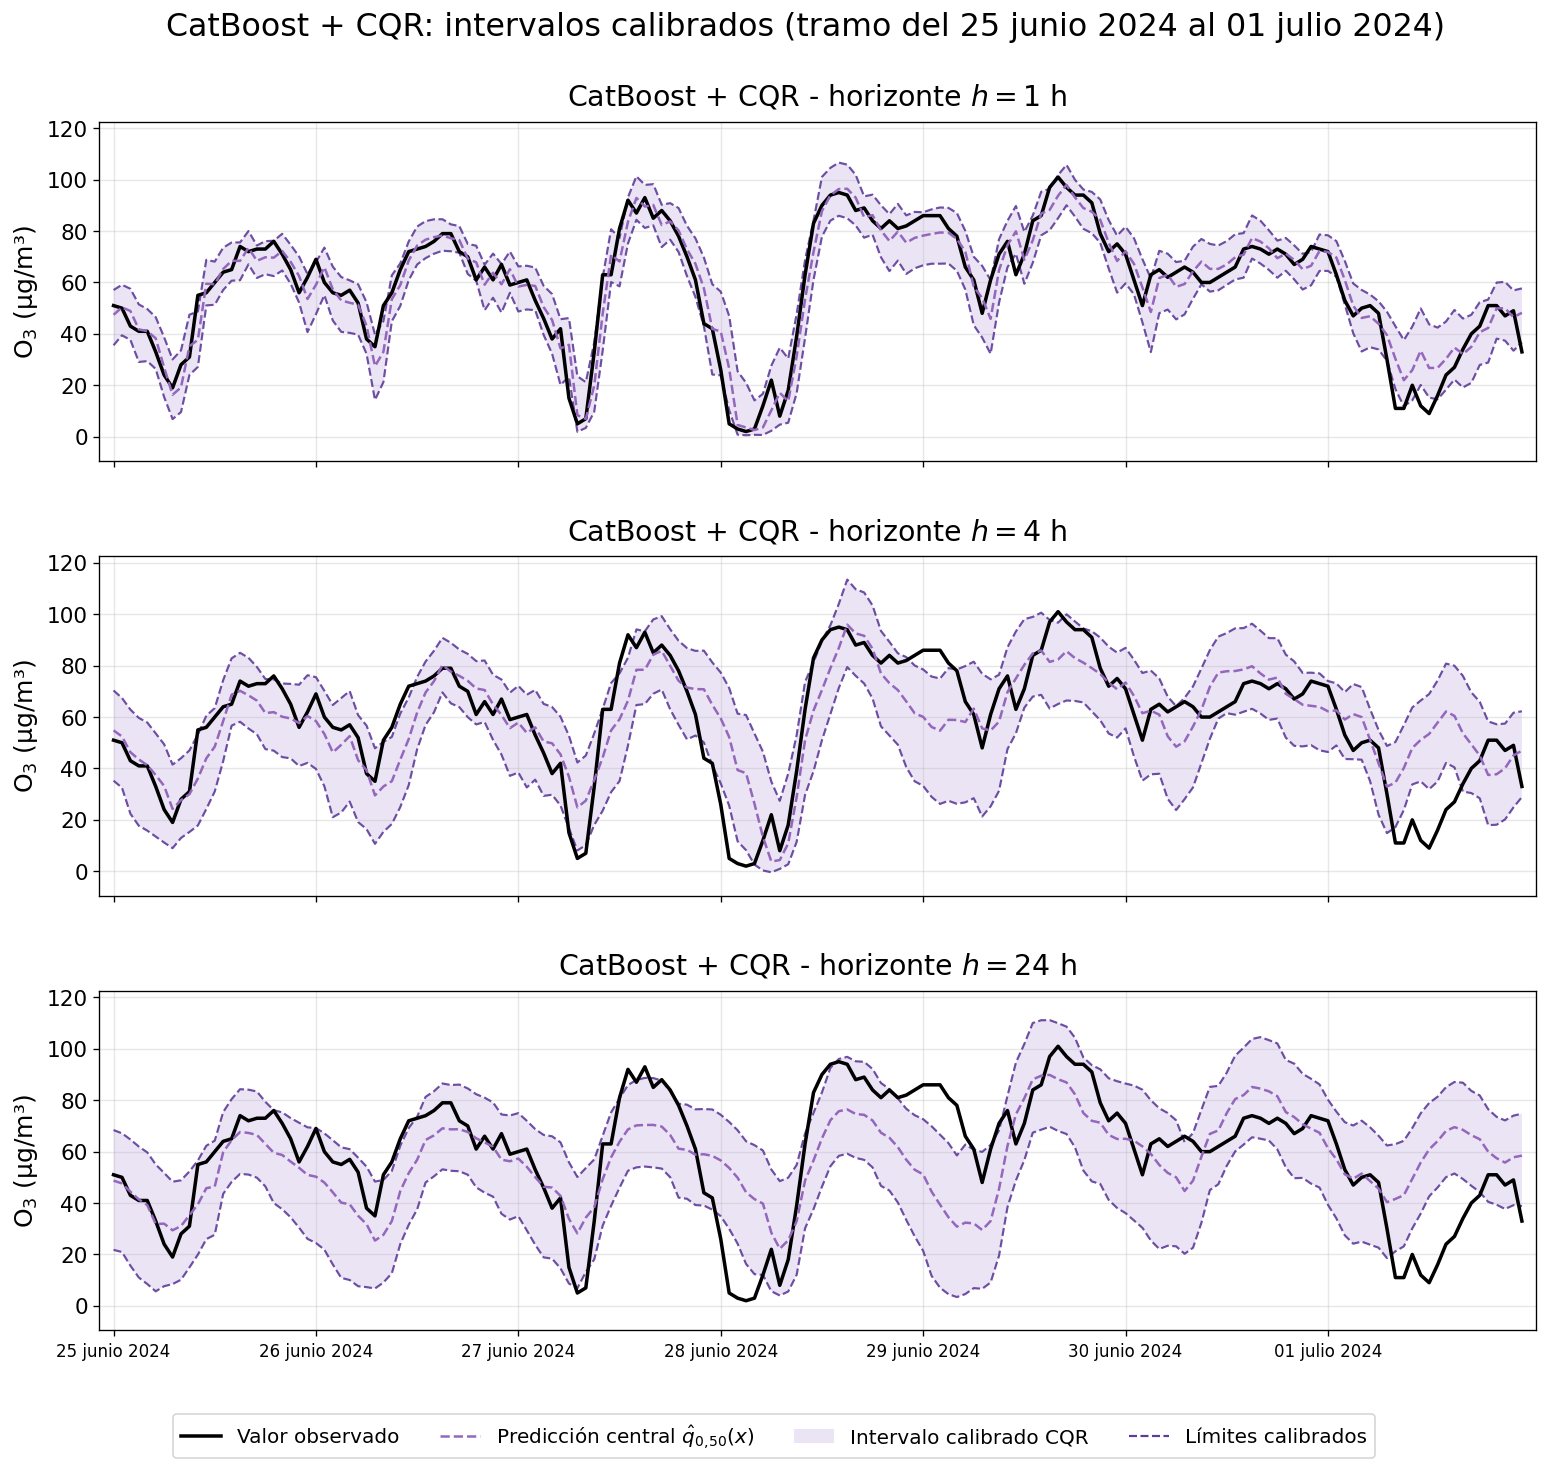

In [35]:

# ==============================================================================
# Figura: intervalos calibrados CatBoost + CQR
# - complementa la figura de cuantiles preliminares
# - permite comprobar visualmente el intervalo final evaluado en las métricas
# ==============================================================================

observed_color = "black"
central_color = MODEL_REGISTRY[CATBOOST_MODEL_ID]["color"]
calibrated_band_color = "#c7b3e5"
calibrated_edge_color = "#5e3c99"

common_ylim = common_ylim_from_blocks(
    [
        block
        for horizon, block in catboost_visual_blocks_by_horizon.items()
        if horizon in CATBOOST_VISUAL_HORIZONS
    ],
    ["y_true", "central_pred", "calibrated_lower", "calibrated_upper"],
)

panel_height = 4.25
fig, axes = plt.subplots(
    len(CATBOOST_VISUAL_HORIZONS),
    1,
    figsize=(13, panel_height * len(CATBOOST_VISUAL_HORIZONS)),
    sharex=True,
    sharey=True,
)

if len(CATBOOST_VISUAL_HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, CATBOOST_VISUAL_HORIZONS):
    block = catboost_visual_blocks_by_horizon[horizon]

    ax.fill_between(
        block["target_timestamp"],
        block["calibrated_lower"],
        block["calibrated_upper"],
        color=calibrated_band_color,
        alpha=0.35,
        edgecolor="none",
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        block["target_timestamp"],
        block["calibrated_lower"],
        color=calibrated_edge_color,
        linewidth=1.3,
        linestyle="--",
        alpha=0.90,
        zorder=2,
    )
    ax.plot(
        block["target_timestamp"],
        block["calibrated_upper"],
        color=calibrated_edge_color,
        linewidth=1.3,
        linestyle="--",
        alpha=0.90,
        zorder=2,
    )
    ax.plot(block["target_timestamp"], block["y_true"], color=observed_color, linewidth=2.1, zorder=4)
    ax.plot(
        block["target_timestamp"],
        block["central_pred"],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        zorder=5,
    )

    ax.set_title(rf"CatBoost + CQR - horizonte $h={horizon}$ h", fontsize=17, pad=10)
    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=15)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=13)
    ax.margins(x=0.01, y=0.06)

# Formato de fechas: se calcula en esta celda para no depender de la figura anterior.
axis_start = min(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).min()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()
axis_end = max(
    pd.to_datetime(catboost_visual_blocks_by_horizon[h]["target_timestamp"]).max()
    for h in CATBOOST_VISUAL_HORIZONS
).normalize()
tick_dates = pd.date_range(start=axis_start, end=axis_end, freq="1D")

for ax in axes:
    configure_spanish_date_axis(ax, tick_dates=tick_dates)

legend_handles = [
    Line2D([0], [0], color=observed_color, linewidth=2.1, label="Valor observado"),
    Line2D(
        [0],
        [0],
        color=central_color,
        linewidth=1.5,
        linestyle="--",
        label=r"Predicción central $\hat{q}_{0{,}50}(x)$",
    ),
    Patch(facecolor=calibrated_band_color, alpha=0.35, label="Intervalo calibrado CQR"),
    Line2D(
        [0],
        [0],
        color=calibrated_edge_color,
        linewidth=1.3,
        linestyle="--",
        label="Límites calibrados",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    fontsize=12,
    frameon=True,
)
fig.suptitle(
    "CatBoost + CQR: intervalos calibrados "
    f"(tramo del {format_spanish_date(CATBOOST_VISUAL_START_TS)} "
    f"al {format_spanish_date(CATBOOST_VISUAL_END_TS)})",
    fontsize=19,
    y=0.972,
    x=0.52,
    ha="center",
)

fig.tight_layout(rect=(0, 0.06, 1, 0.95))
fig.subplots_adjust(hspace=0.28, top=0.90, bottom=0.11)

cqr_intervals_fig_path = REPORTS_FIGURES_DIR / "fig_catboost_cqr_intervals_h01_h04_h24.png"
save_figure(fig, cqr_intervals_fig_path)
plt.show()


In [36]:

# ==============================================================================
# Tabla: métricas de los intervalos cuantílicos preliminares de los modelos supervisados
# ==============================================================================

# Modelos supervisados considerados: se excluye el modelo base.
supervised_model_ids = [model_id for model_id in MODEL_ORDER if model_id != "baseline_seasonal_naive"]

# Columnas que contienen los límites preliminares de QR.
# En este notebook deberían ser lower_prelim y upper_prelim.
prelim_lower_col = first_existing_column(
    common_intervals,
    [
        "lower_prelim",
        "prelim_lower",
        "y_pred_quantile_lower",
        "y_pred_lower",
        "quantile_lower",
        "lower_quantile",
        "q_lower",
    ],
    purpose="límite inferior QR preliminar",
)
prelim_upper_col = first_existing_column(
    common_intervals,
    [
        "upper_prelim",
        "prelim_upper",
        "y_pred_quantile_upper",
        "y_pred_upper",
        "quantile_upper",
        "upper_quantile",
        "q_upper",
    ],
    purpose="límite superior QR preliminar",
)

print(f"Columna usada como límite inferior QR: {prelim_lower_col}")
print(f"Columna usada como límite superior QR: {prelim_upper_col}")

qr_preliminary_rows = []

for horizon in HORIZONS:
    for model_id in supervised_model_ids:
        block = common_intervals.loc[
            (common_intervals["horizon"] == horizon)
            & (common_intervals["model"] == model_id)
        ].copy()

        if block.empty:
            raise ValueError(f"No hay datos para el modelo {model_id} en h={horizon}.")

        eval_block = block[["y_true", prelim_lower_col, prelim_upper_col]].dropna().copy()

        if eval_block.empty:
            raise ValueError(
                f"No quedan observaciones válidas para {model_id}, h={horizon}, "
                "tras eliminar valores nulos."
            )

        qr_covered = (
            (eval_block["y_true"] >= eval_block[prelim_lower_col])
            & (eval_block["y_true"] <= eval_block[prelim_upper_col])
        )
        qr_width = eval_block[prelim_upper_col] - eval_block[prelim_lower_col]
        qr_scores = interval_score(
            eval_block["y_true"],
            eval_block[prelim_lower_col],
            eval_block[prelim_upper_col],
            ALPHA,
        )

        qr_preliminary_rows.append(
            {
                "horizon": horizon,
                "model": model_id,
                "model_label": get_model_label(model_id),
                "n_samples": len(eval_block),
                "qr_coverage": float(qr_covered.mean()),
                "qr_mean_width": float(qr_width.mean()),
                "qr_mean_interval_score": float(np.mean(qr_scores)),
            }
        )

qr_preliminary_metrics_df = sort_by_horizon_and_model(pd.DataFrame(qr_preliminary_rows))

# Versión redondeada para visualizar y copiar a la memoria.
qr_preliminary_metrics_display = qr_preliminary_metrics_df.copy()
round_cols = ["qr_coverage", "qr_mean_width", "qr_mean_interval_score"]
qr_preliminary_metrics_display[round_cols] = qr_preliminary_metrics_display[round_cols].round(3)
qr_preliminary_metrics_display = (
    qr_preliminary_metrics_display[
        [
            "horizon",
            "model_label",
            "n_samples",
            "qr_coverage",
            "qr_mean_width",
            "qr_mean_interval_score",
        ]
    ]
    .rename(
        columns={
            "horizon": "Horizonte",
            "model_label": "Modelo",
            "n_samples": "n",
            "qr_coverage": "Cobertura QR",
            "qr_mean_width": "Anchura media QR",
            "qr_mean_interval_score": "Interval score QR",
        }
    )
)

print("Métricas de los intervalos cuantílicos preliminares sobre los instantes objetivo comunes:")
display(qr_preliminary_metrics_display)

# Guardado de la tabla completa.
qr_preliminary_metrics_path = REPORTS_TABLES_DIR / "qr_preliminary_supervised_metrics_validation_common.csv"
save_dataframe_csv(qr_preliminary_metrics_df, qr_preliminary_metrics_path, index=False)


Columna usada como límite inferior QR: lower_prelim
Columna usada como límite superior QR: upper_prelim
Métricas de los intervalos cuantílicos preliminares sobre los instantes objetivo comunes:


,Horizonte,Modelo,n,Cobertura QR,Anchura media QR,Interval score QR
0,1,Regresión lineal,8265,0.792,20.899,32.489
1,1,LightGBM,8265,0.772,18.833,30.008
2,1,CatBoost,8265,0.770,18.572,29.807
3,4,Regresión lineal,8265,0.792,40.545,55.096
4,4,LightGBM,8265,0.753,34.891,51.073
5,4,CatBoost,8265,0.740,33.132,50.346
6,12,Regresión lineal,8265,0.789,45.013,60.488
7,12,LightGBM,8265,0.735,39.883,58.805
8,12,CatBoost,8265,0.717,37.639,58.467
9,24,Regresión lineal,8265,0.783,45.582,61.819


Tabla guardada: c:\trabajo_github\reports\tables\qr_preliminary_supervised_metrics_validation_common.csv


WindowsPath('c:/trabajo_github/reports/tables/qr_preliminary_supervised_metrics_validation_common.csv')


## Conclusión preliminar

La siguiente tabla hace un resumen de la selección preliminar por horizonte de acuerdo con el interval score calculado sobre los instantes objetivo comunes.


In [37]:

# Resumen de la selección preliminar

selection_summary_df = best_method_by_horizon_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "coverage_error",
    ]
].copy()
selection_summary_df = selection_summary_df.rename(
    columns={
        "label": "selected_method",
        "n_samples": "n_common_samples",
    }
)

# Se añade también el mejor método global según la media del interval score.
overall_ranking_df = (
    common_metrics_df.groupby(["model", "label"], as_index=False)
    .agg(
        mean_interval_score_across_horizons=("mean_interval_score", "mean"),
        mean_width_across_horizons=("mean_width", "mean"),
        mean_coverage_across_horizons=("empirical_coverage", "mean"),
    )
    .sort_values(
        ["mean_interval_score_across_horizons", "mean_width_across_horizons"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)
overall_ranking_df["global_rank"] = np.arange(1, len(overall_ranking_df) + 1)

selection_summary_path = REPORTS_TABLES_DIR / "interval_selection_summary.csv"
overall_ranking_path = REPORTS_TABLES_DIR / "interval_overall_ranking.csv"
save_dataframe_csv(selection_summary_df, selection_summary_path, index=False)
save_dataframe_csv(overall_ranking_df, overall_ranking_path, index=False)

print("Selección preliminar por horizonte:")
display(selection_summary_df)

print("Ranking global por media del interval score:")
display(overall_ranking_df)


Tabla guardada: c:\trabajo_github\reports\tables\interval_selection_summary.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_overall_ranking.csv
Selección preliminar por horizonte:


,horizon,selected_method,n_common_samples,empirical_coverage,mean_width,mean_interval_score,coverage_error
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,0.002
1,4,CatBoost + CQR,8265,0.790,35.902,49.886,-0.010
2,12,CatBoost + CQR,8265,0.796,42.207,57.559,-0.004
3,24,CatBoost + CQR,8265,0.779,43.010,59.237,-0.021


Ranking global por media del interval score:


,model,label,mean_interval_score_across_horizons,mean_width_across_horizons,mean_coverage_across_horizons,global_rank
0,catboost,CatBoost + CQR,49.106,35.219,0.792,1
1,lightgbm,LightGBM + CQR,49.768,35.857,0.792,2
2,linear_regression,Regresión lineal + CQR,52.462,38.371,0.794,3
3,baseline_seasonal_naive,Modelo base + SC,79.195,54.000,0.800,4


Tramo visual seleccionado: 2024-06-26 00:00:00 → 2024-06-27 23:00:00 (48 horas)
Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_cqr_effect_simplified_h01_h04_h24.png
Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_cqr_effect_h04.png


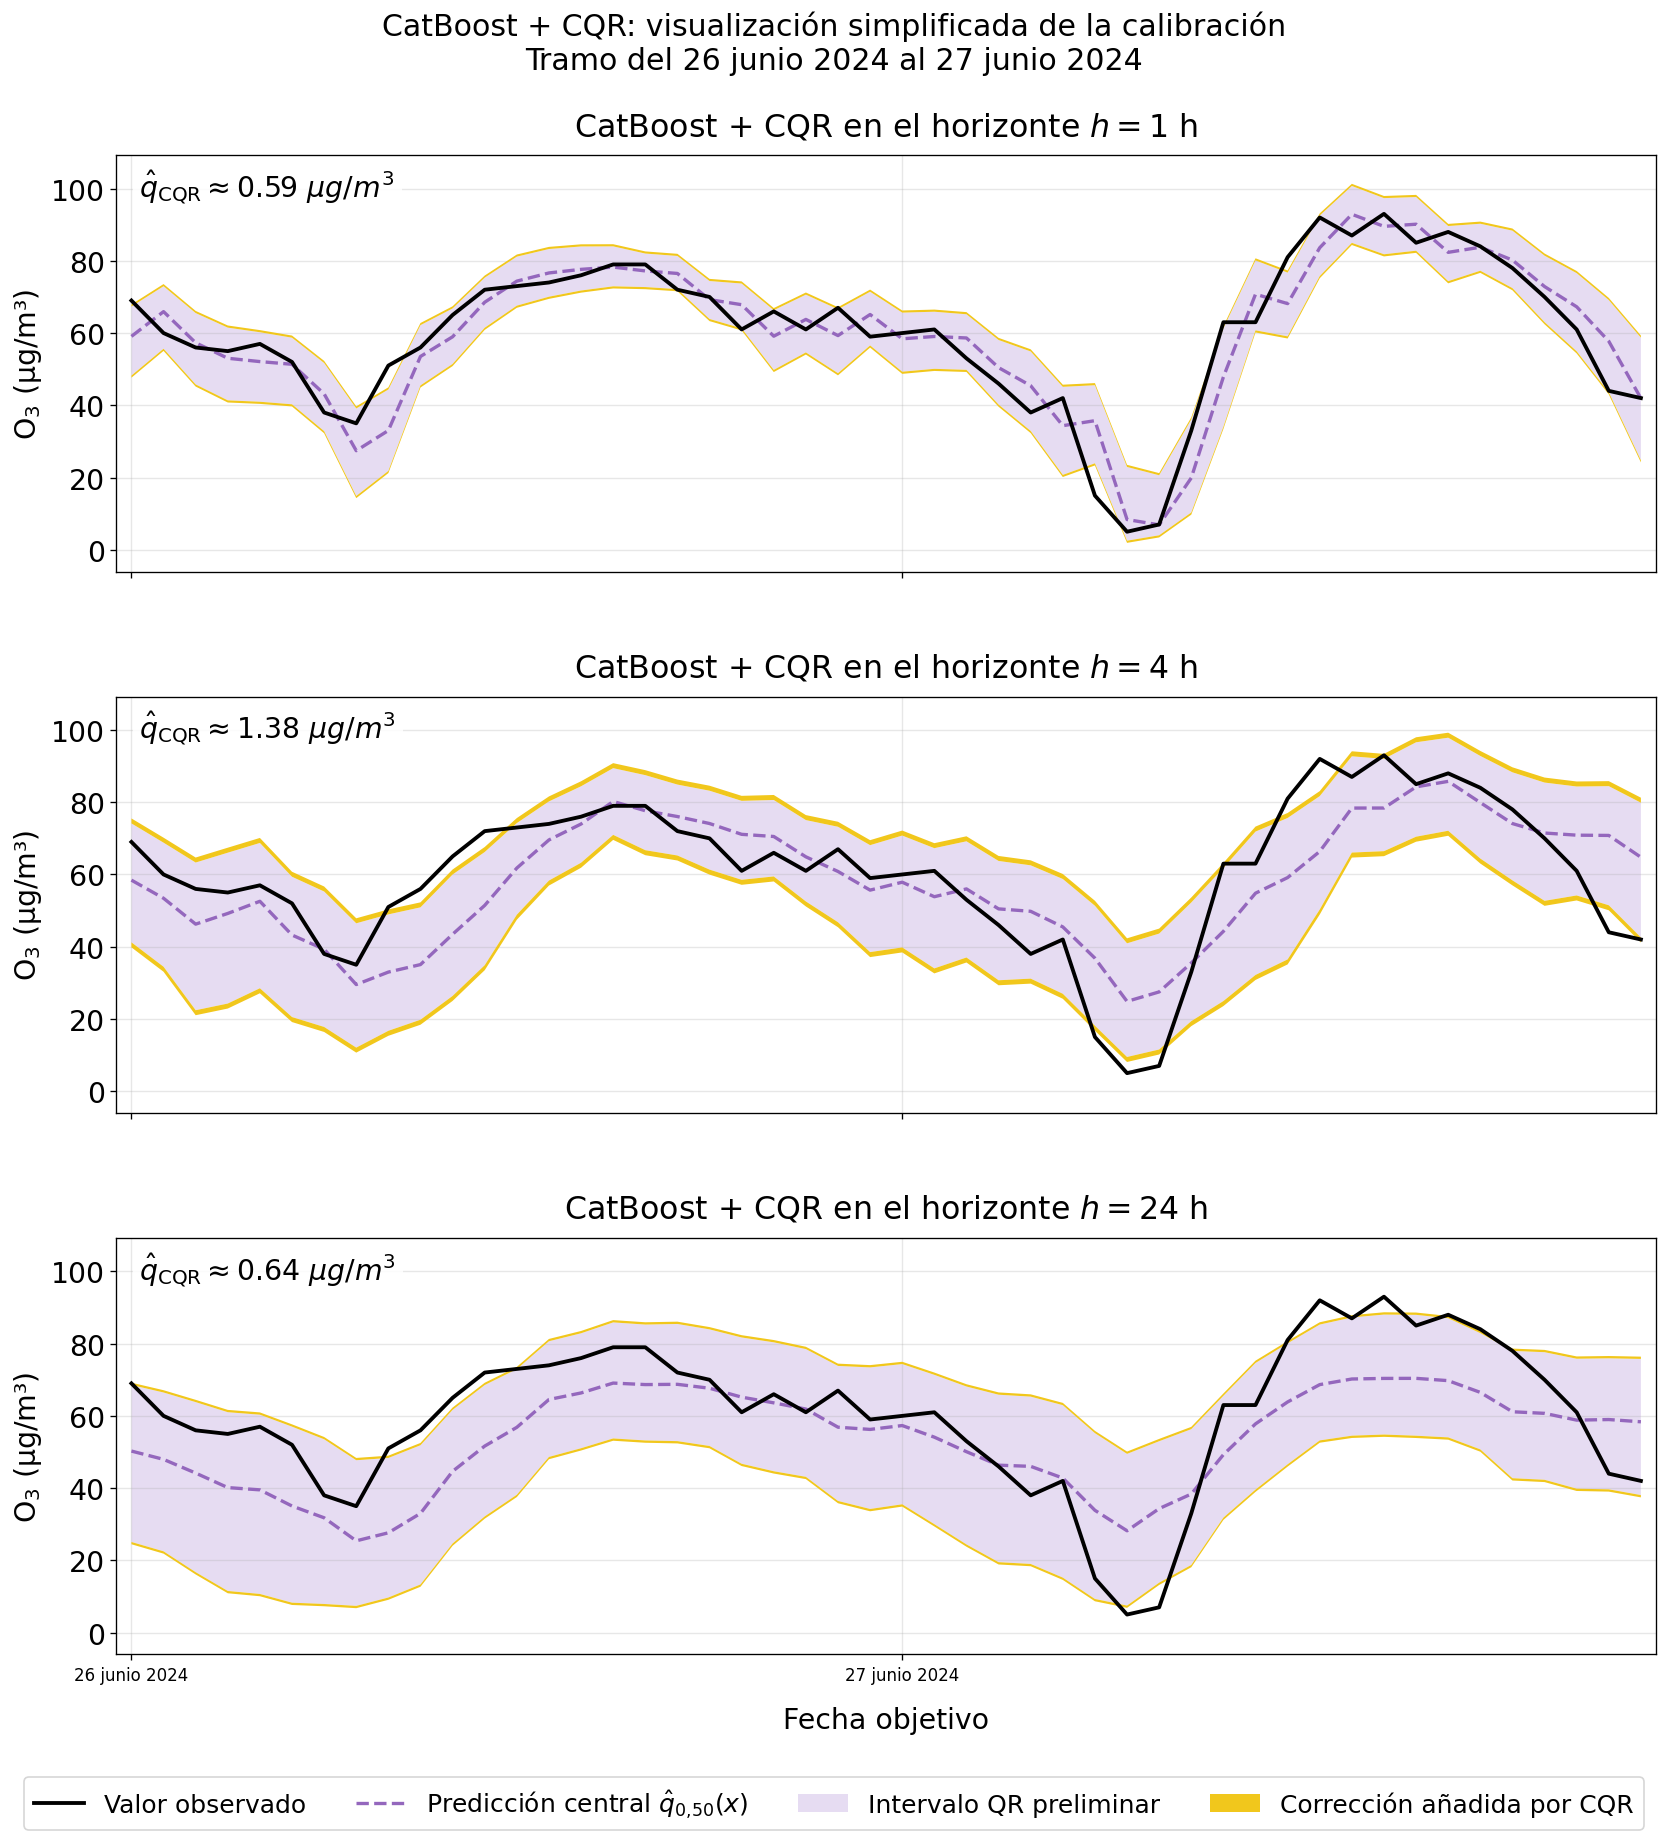

In [38]:

# ==============================================================================
# Figura: visualización simplificada del efecto de CQR en CatBoost
# - tres horizontes: h = 1, h = 4 y h = 24
# - ventana corta común
# - sin líneas de cuantiles ni bordes de intervalos
# - morado = intervalo QR preliminar
# - amarillo = corrección añadida por CQR
# ==============================================================================

# ------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------
SELECTED_HORIZONS = [1, 4, 24]
N_DAYS_TO_SHOW = 2

# 0 = empezar al inicio del tramo maestro.
# 1 = empezar un día después, etc.
VISUAL_START_OFFSET_DAYS = 1

# Altura de cada panel.
PANEL_HEIGHT = 5.5

# ------------------------------------------------------------------
# Comprobación de horizontes disponibles
# ------------------------------------------------------------------
missing_horizons = [
    horizon
    for horizon in SELECTED_HORIZONS
    if horizon not in catboost_visual_blocks_by_horizon
]

if missing_horizons:
    raise KeyError(
        f"Faltan bloques visuales para los horizontes {missing_horizons}. "
        f"Horizontes disponibles: {list(catboost_visual_blocks_by_horizon.keys())}"
    )

# ------------------------------------------------------------------
# Se define una ventana temporal común para todos los horizontes
# ------------------------------------------------------------------
horizon_start_times = []
horizon_end_times = []

for horizon in SELECTED_HORIZONS:
    block_h = catboost_visual_blocks_by_horizon[horizon].copy()
    block_h["target_timestamp"] = pd.to_datetime(block_h["target_timestamp"])
    horizon_start_times.append(block_h["target_timestamp"].min())
    horizon_end_times.append(block_h["target_timestamp"].max())

common_start_ts = max(horizon_start_times)
common_end_available_ts = min(horizon_end_times)

start_ts = common_start_ts + pd.Timedelta(days=VISUAL_START_OFFSET_DAYS)
end_ts = start_ts + pd.Timedelta(days=N_DAYS_TO_SHOW) - pd.Timedelta(hours=1)

if end_ts > common_end_available_ts:
    raise ValueError(
        f"La ventana solicitada termina en {end_ts}, pero el último timestamp común "
        f"disponible es {common_end_available_ts}. Reduce N_DAYS_TO_SHOW o "
        f"VISUAL_START_OFFSET_DAYS."
    )

expected_hours = N_DAYS_TO_SHOW * 24
visual_blocks_by_horizon = {}

for horizon in SELECTED_HORIZONS:
    block_h = catboost_visual_blocks_by_horizon[horizon].copy()
    block_h = block_h.sort_values("target_timestamp").reset_index(drop=True)
    block_h["target_timestamp"] = pd.to_datetime(block_h["target_timestamp"])
    block_h = block_h.loc[
        (block_h["target_timestamp"] >= start_ts)
        & (block_h["target_timestamp"] <= end_ts)
    ].copy()

    if len(block_h) != expected_hours:
        raise ValueError(
            f"El bloque para h={horizon} tiene {len(block_h)} observaciones, "
            f"pero se esperaban {expected_hours}. Revisa la continuidad del tramo."
        )

    visual_blocks_by_horizon[horizon] = block_h

print("Tramo visual seleccionado:", start_ts, "→", end_ts, f"({expected_hours} horas)")

# ------------------------------------------------------------------
# Colores
# ------------------------------------------------------------------
observed_color = "black"
central_color = MODEL_REGISTRY[CATBOOST_MODEL_ID]["color"]   # color CatBoost
qr_band_color = "#8e63c7"     # morado
cqr_add_color = "#f1c40f"     # amarillo

# ------------------------------------------------------------------
# Rango vertical común para los tres paneles
# ------------------------------------------------------------------
common_ylim = common_ylim_from_blocks(
    visual_blocks_by_horizon.values(),
    [
        "y_true",
        "central_pred",
        "prelim_lower",
        "prelim_upper",
        "calibrated_lower",
        "calibrated_upper",
    ],
)

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    len(SELECTED_HORIZONS),
    1,
    figsize=(14, PANEL_HEIGHT * len(SELECTED_HORIZONS)),
    sharex=True,
    sharey=True,
)

if len(SELECTED_HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, SELECTED_HORIZONS):
    block = visual_blocks_by_horizon[horizon]

    # ------------------------------------------------------------------
    # Corrección CQR
    # ------------------------------------------------------------------
    lower_delta = block["prelim_lower"] - block["calibrated_lower"]
    upper_delta = block["calibrated_upper"] - block["prelim_upper"]
    q_cqr = (lower_delta.median() + upper_delta.median()) / 2

    # --------------------------------------------------------------
    # 1) Intervalo QR preliminar (banda morada)
    # --------------------------------------------------------------
    ax.fill_between(
        block["target_timestamp"],
        block["prelim_lower"],
        block["prelim_upper"],
        color=qr_band_color,
        alpha=0.22,
        edgecolor="none",
        linewidth=0,
        zorder=1,
    )

    # --------------------------------------------------------------
    # 2) Corrección añadida por CQR (banda amarilla)
    # --------------------------------------------------------------
    ax.fill_between(
        block["target_timestamp"],
        block["calibrated_lower"],
        block["prelim_lower"],
        color=cqr_add_color,
        alpha=0.95,
        edgecolor="none",
        linewidth=0,
        zorder=2,
    )
    ax.fill_between(
        block["target_timestamp"],
        block["prelim_upper"],
        block["calibrated_upper"],
        color=cqr_add_color,
        alpha=0.95,
        edgecolor="none",
        linewidth=0,
        zorder=2,
    )

    # --------------------------------------------------------------
    # 3) Valor observado
    # --------------------------------------------------------------
    ax.plot(block["target_timestamp"], block["y_true"], color=observed_color, linewidth=2.3, zorder=5)

    # --------------------------------------------------------------
    # 4) Predicción central
    # --------------------------------------------------------------
    ax.plot(
        block["target_timestamp"],
        block["central_pred"],
        color=central_color,
        linewidth=2.0,
        linestyle="--",
        zorder=4,
    )

    # --------------------------------------------------------------
    # Texto con la corrección aproximada
    # --------------------------------------------------------------
    ax.text(
        0.015,
        0.90,
        rf"$\hat{{q}}_{{\mathrm{{CQR}}}} \approx {q_cqr:.2f}$ $\mu g/m^3$",
        transform=ax.transAxes,
        fontsize=17,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=4),
    )

    # ------------------------------------------------------------------
    # Formato del panel
    # ------------------------------------------------------------------
    ax.set_title(rf"CatBoost + CQR en el horizonte $h={horizon}$ h", fontsize=19, pad=12)
    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=17)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=17)
    ax.margins(x=0.01, y=0.08)

axes[-1].set_xlabel("Fecha objetivo", fontsize=17, labelpad=13)

# ------------------------------------------------------------------
# Formato de fechas
# ------------------------------------------------------------------
date_locator = mdates.DayLocator(interval=1)
for ax in axes:
    configure_spanish_date_axis(ax, locator=date_locator)

# ------------------------------------------------------------------
# Leyenda debajo de la figura
# ------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=observed_color, linewidth=2.3, label="Valor observado"),
    Line2D(
        [0],
        [0],
        color=central_color,
        linewidth=2.0,
        linestyle="--",
        label=r"Predicción central $\hat{q}_{0{,}50}(x)$",
    ),
    Patch(facecolor=qr_band_color, alpha=0.22, label="Intervalo QR preliminar"),
    Patch(facecolor=cqr_add_color, alpha=0.95, label="Corrección añadida por CQR"),
]
legend = fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    fontsize=15,
    frameon=True,
)

# ------------------------------------------------------------------
# Título general
# ------------------------------------------------------------------
fig.suptitle(
    "CatBoost + CQR: visualización simplificada de la calibración\n"
    f"Tramo del {format_spanish_date(start_ts)} al {format_spanish_date(end_ts)}",
    fontsize=18,
    y=0.94,
)

# ------------------------------------------------------------------
# Ajuste del espacio de la figura
# ------------------------------------------------------------------
fig.tight_layout(rect=(0, 0.07, 1, 0.94))
fig.subplots_adjust(hspace=0.30, bottom=0.11)

cqr_effect_zoom_path = REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_simplified_h01_h04_h24.png"
legacy_cqr_effect_zoom_path = REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_h04.png"
save_figure(
    fig,
    cqr_effect_zoom_path,
    aliases=[legacy_cqr_effect_zoom_path],
    bbox_extra_artists=(legend,),
)
plt.show()


In [39]:

# Comparación global entre intervalos QR preliminares e intervalos CQR calibrados
# ==============================================================================
# Esta salida rápida complementa la tabla de métricas preliminares y sirve como
# comprobación de que la calibración CQR aumenta la cobertura de CatBoost.

catboost_prelim_lower_col = first_existing_column(
    common_intervals,
    ["lower_prelim", "prelim_lower", "y_pred_quantile_lower", "y_pred_lower"],
    purpose="límite inferior preliminar de CatBoost",
)
catboost_prelim_upper_col = first_existing_column(
    common_intervals,
    ["upper_prelim", "prelim_upper", "y_pred_quantile_upper", "y_pred_upper"],
    purpose="límite superior preliminar de CatBoost",
)

for horizon in [1, 4, 24]:
    block_all = common_intervals.loc[
        (common_intervals["model"] == "catboost")
        & (common_intervals["horizon"] == horizon)
    ].copy()

    prelim_covered = (
        (block_all["y_true"] >= block_all[catboost_prelim_lower_col])
        & (block_all["y_true"] <= block_all[catboost_prelim_upper_col])
    )
    calibrated_covered = (
        (block_all["y_true"] >= block_all["lower"])
        & (block_all["y_true"] <= block_all["upper"])
    )

    prelim_width = (block_all[catboost_prelim_upper_col] - block_all[catboost_prelim_lower_col]).mean()
    calibrated_width = (block_all["upper"] - block_all["lower"]).mean()

    print(f"\nHorizonte h={horizon}")
    print(f"N observaciones comunes:     {len(block_all)}")
    print(f"Anchura preliminar media:    {prelim_width:.4f}")
    print(f"Anchura calibrada media:     {calibrated_width:.4f}")
    print(f"Cobertura preliminar global: {prelim_covered.mean():.4f}")
    print(f"Cobertura calibrada global:  {calibrated_covered.mean():.4f}")



Horizonte h=1
N observaciones comunes:     8265
Anchura preliminar media:    18.5719
Anchura calibrada media:     19.7592
Cobertura preliminar global: 0.7700
Cobertura calibrada global:  0.8017

Horizonte h=4
N observaciones comunes:     8265
Anchura preliminar media:    33.1324
Anchura calibrada media:     35.9022
Cobertura preliminar global: 0.7395
Cobertura calibrada global:  0.7898

Horizonte h=24
N observaciones comunes:     8265
Anchura preliminar media:    41.7363
Anchura calibrada media:     43.0097
Cobertura preliminar global: 0.7532
Cobertura calibrada global:  0.7792


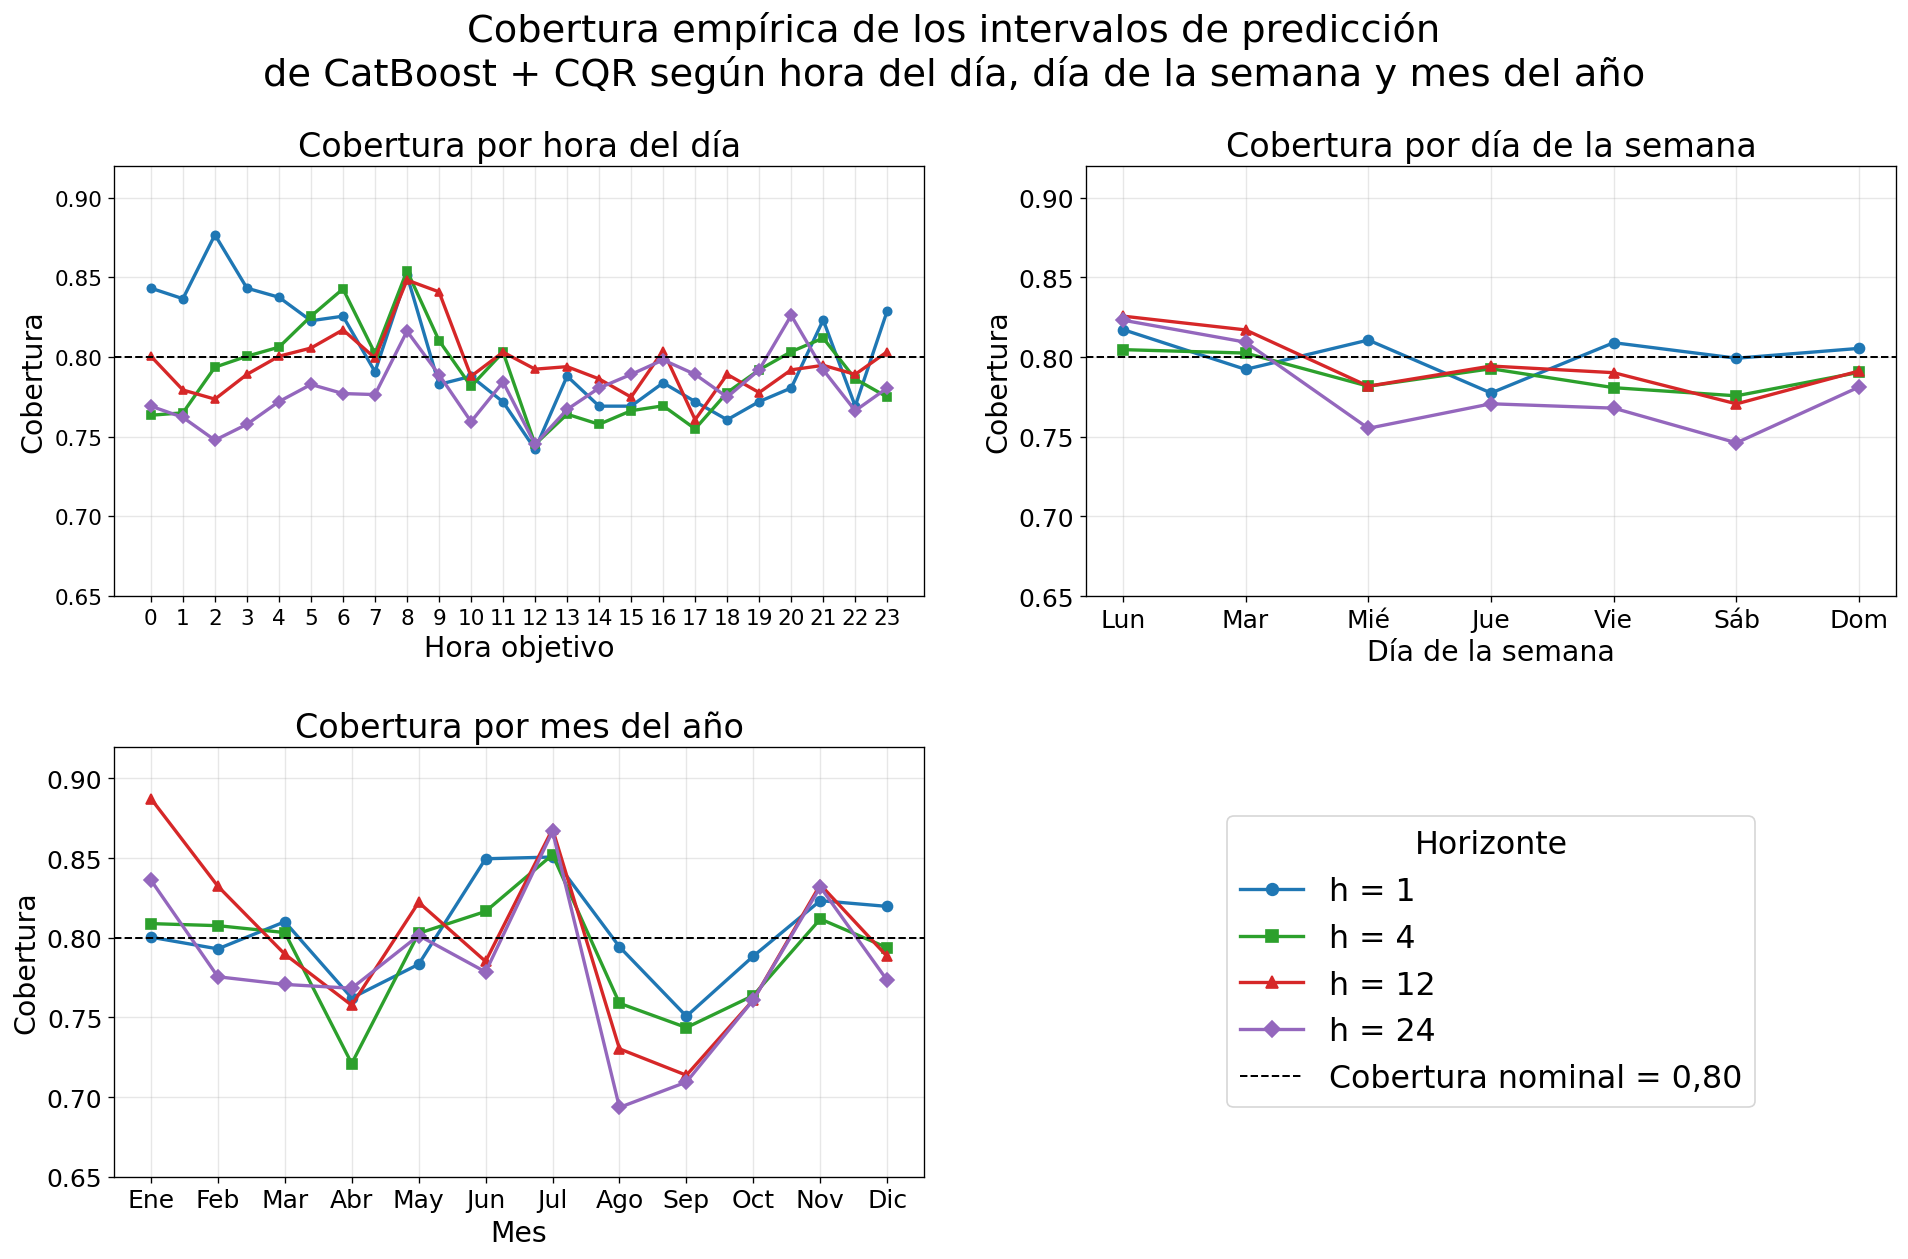

Figura guardada en: c:\trabajo_github\reports\figures\fig_catboost_cqr_coverage_temporal_patterns.png


In [65]:
# ==============================================================================
# Figura: cobertura empírica de CatBoost + CQR
# según hora del día, día de la semana y mes del año
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Configuración
# ------------------------------------------------------------------
SELECTED_MODEL = "catboost"
SELECTED_HORIZONS = [1, 4, 12, 24]
NOMINAL_COVERAGE = 0.80

# Colores por horizonte (puedes cambiarlos si quieres)
HORIZON_COLORS = {
    1: "#1f77b4",   # azul
    4: "#2ca02c",   # verde
    12: "#d62728",  # rojo
    24: "#9467bd",  # morado
}

HORIZON_MARKERS = {
    1: "o",
    4: "s",
    12: "^",
    24: "D",
}

# ------------------------------------------------------------------
# Filtrado de datos
# ------------------------------------------------------------------
catboost_df = common_intervals.loc[
    common_intervals["model"] == SELECTED_MODEL
].copy()

catboost_df["target_timestamp"] = pd.to_datetime(catboost_df["target_timestamp"])

# Variables temporales auxiliares
catboost_df["hour"] = catboost_df["target_timestamp"].dt.hour
catboost_df["weekday"] = catboost_df["target_timestamp"].dt.dayofweek   # lunes=0
catboost_df["month"] = catboost_df["target_timestamp"].dt.month

# Etiquetas en español
weekday_labels = {
    0: "Lun",
    1: "Mar",
    2: "Mié",
    3: "Jue",
    4: "Vie",
    5: "Sáb",
    6: "Dom",
}

month_labels = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

# ------------------------------------------------------------------
# Cálculo de coberturas agregadas
# ------------------------------------------------------------------
coverage_by_hour = (
    catboost_df
    .groupby(["horizon", "hour"], as_index=False)["covered"]
    .mean()
    .rename(columns={"covered": "coverage"})
)

coverage_by_weekday = (
    catboost_df
    .groupby(["horizon", "weekday"], as_index=False)["covered"]
    .mean()
    .rename(columns={"covered": "coverage"})
)

coverage_by_month = (
    catboost_df
    .groupby(["horizon", "month"], as_index=False)["covered"]
    .mean()
    .rename(columns={"covered": "coverage"})
)

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 11),
    gridspec_kw={"height_ratios": [1, 1], "width_ratios": [1, 1]}
)

ax_hour = axes[0, 0]
ax_weekday = axes[0, 1]
ax_month = axes[1, 0]
ax_legend = axes[1, 1]

# Título general
fig.suptitle(
    "Cobertura empírica de los intervalos de predicción\n"
    "de CatBoost + CQR según hora del día, día de la semana y mes del año",
    fontsize=23,
    y=0.95
)

# ------------------------------------------------------------------
# Panel 1: cobertura por hora del día
# ------------------------------------------------------------------
for h in SELECTED_HORIZONS:
    df_h = coverage_by_hour.loc[coverage_by_hour["horizon"] == h].copy()
    df_h = df_h.sort_values("hour")

    ax_hour.plot(
        df_h["hour"],
        df_h["coverage"],
        marker=HORIZON_MARKERS[h],
        markersize=5,
        linewidth=2,
        color=HORIZON_COLORS[h],
        label=f"h = {h}"
    )

ax_hour.axhline(NOMINAL_COVERAGE, color="black", linestyle="--", linewidth=1.2)
ax_hour.set_title("Cobertura por hora del día", fontsize=20)
ax_hour.set_xlabel("Hora objetivo", fontsize=17)
ax_hour.set_ylabel("Cobertura", fontsize=17)
ax_hour.set_xticks(range(24))
ax_hour.tick_params(axis="both", labelsize=13)
ax_hour.grid(True, alpha=0.3)
ax_hour.set_ylim(0.65, 0.92)

# ------------------------------------------------------------------
# Panel 2: cobertura por día de la semana
# ------------------------------------------------------------------
for h in SELECTED_HORIZONS:
    df_h = coverage_by_weekday.loc[coverage_by_weekday["horizon"] == h].copy()
    df_h = df_h.sort_values("weekday")

    ax_weekday.plot(
        df_h["weekday"],
        df_h["coverage"],
        marker=HORIZON_MARKERS[h],
        markersize=6,
        linewidth=2,
        color=HORIZON_COLORS[h],
        label=f"h = {h}"
    )

ax_weekday.axhline(NOMINAL_COVERAGE, color="black", linestyle="--", linewidth=1.2)
ax_weekday.set_title("Cobertura por día de la semana", fontsize=20)
ax_weekday.set_xlabel("Día de la semana", fontsize=17)
ax_weekday.set_ylabel("Cobertura", fontsize=17)
ax_weekday.set_xticks(list(weekday_labels.keys()))
ax_weekday.set_xticklabels(list(weekday_labels.values()))
ax_weekday.tick_params(axis="both", labelsize=15)
ax_weekday.grid(True, alpha=0.3)
ax_weekday.set_ylim(0.65, 0.92)

# ------------------------------------------------------------------
# Panel 3: cobertura por mes del año
# ------------------------------------------------------------------
for h in SELECTED_HORIZONS:
    df_h = coverage_by_month.loc[coverage_by_month["horizon"] == h].copy()
    df_h = df_h.sort_values("month")

    ax_month.plot(
        df_h["month"],
        df_h["coverage"],
        marker=HORIZON_MARKERS[h],
        markersize=6,
        linewidth=2,
        color=HORIZON_COLORS[h],
        label=f"h = {h}"
    )

ax_month.axhline(NOMINAL_COVERAGE, color="black", linestyle="--", linewidth=1.2)
ax_month.set_title("Cobertura por mes del año", fontsize=20)
ax_month.set_xlabel("Mes", fontsize=17)
ax_month.set_ylabel("Cobertura", fontsize=17)
ax_month.set_xticks(list(month_labels.keys()))
ax_month.set_xticklabels(list(month_labels.values()))
ax_month.tick_params(axis="both", labelsize=15)
ax_month.grid(True, alpha=0.3)
ax_month.set_ylim(0.65, 0.92)

# ------------------------------------------------------------------
# Panel 4: leyenda
# ------------------------------------------------------------------
ax_legend.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color=HORIZON_COLORS[h],
        marker=HORIZON_MARKERS[h],
        linewidth=2,
        markersize=7,
        label=f"h = {h}"
    )
    for h in SELECTED_HORIZONS
]

legend_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Cobertura nominal = 0,80"
    )
)

ax_legend.legend(
    handles=legend_handles,
    title="Horizonte",
    loc="center",
    frameon=True,
    fontsize=19,
    title_fontsize=19
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.subplots_adjust(
    wspace=0.2,  # separación horizontal entre columnas
    hspace=0.35,  # separación vertical entre filas
)

# ------------------------------------------------------------------
# Guardado opcional
# ------------------------------------------------------------------
output_path = REPORTS_FIGURES_DIR / "fig_catboost_cqr_coverage_temporal_patterns.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {output_path}")

In [40]:

# Comprobaciones finales
# ==============================================================================
assert not validation_intervals.empty, "No se han cargado los intervalos de validación."
assert not available_metrics_df.empty, "La tabla de métricas disponibles está vacía."
assert not common_metrics_df.empty, "La tabla de métricas comunes está vacía."
assert len(common_metrics_df) == len(MODEL_ORDER) * len(HORIZONS), "Faltan combinaciones modelo-horizonte en la comparación principal."
assert (common_metrics_df["n_samples"] > 0).all(), "Algún método carece de observaciones comunes."
assert (comparison_target_counts_df["n_common_targets"] > 0).all(), "Algún horizonte no tiene instantes comunes."

expected_figure_paths = [
    REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_split_conformal_baseline_selected_window_all_horizons.png",
    REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png",
    REPORTS_FIGURES_DIR / "fig_catboost_quantiles_prelim_h01_h04_h24.png",
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_intervals_h01_h04_h24.png",
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_simplified_h01_h04_h24.png",
    REPORTS_FIGURES_DIR / "fig_catboost_cqr_effect_h04.png",
]
missing_figures = [path for path in expected_figure_paths if not path.exists()]
assert not missing_figures, f"Faltan figuras: {missing_figures}"

print("Comprobaciones finales superadas correctamente.")
print("- Se han comparado todos los métodos sobre validación 2024.")
print("- La comparación principal se ha construido sobre instantes objetivo comunes.")
print("- Se han guardado tablas comparativas y figuras para la memoria.")
print("- Queda preparado el material para la redacción de resultados de intervalos.")


Comprobaciones finales superadas correctamente.
- Se han comparado todos los métodos sobre validación 2024.
- La comparación principal se ha construido sobre instantes objetivo comunes.
- Se han guardado tablas comparativas y figuras para la memoria.
- Queda preparado el material para la redacción de resultados de intervalos.
